<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch02_bagging_random_forests_enhanced_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Homogeneous Parallel Ensembles -- Bagging and Random Forests

*Companion notebook to Kunapuli, **Ensemble Methods for Machine Learning** (Manning, 2023).*

**Where we left off in Chapter 1.** Six *heterogeneous* learners (KRR, SVR, DTR, KNN, GPR, MLP) trained independently and averaged. The ensemble was *guaranteed* to beat the average member ($+9.22$ pp on Friedman-1) but could not always beat the best member -- because no single number weighted the more competent learners more. We met two formulas that will reappear *every* time we touch an ensemble:

- **Variance of the mean of $K$ correlated estimators.** $\mathrm{Var}\bigl(\frac{1}{K}\sum_k f_k\bigr) = \rho\sigma_f^2 + \tfrac{1-\rho}{K}\sigma_f^2$.
- **Krogh-Vedelsby ambiguity decomposition.** $\text{ensemble MSE} = \overline{E} - \overline{A}$ exactly, with $\overline{A} \ge 0$ always.

**What changes in Chapter 2.** Instead of mixing different *families* of learners we now use $K$ copies of **the same** algorithm. The diversity that makes the ensemble work no longer comes from "different models look at the data differently" -- it comes from **deliberately changing the *data*** each base learner sees:

- **Bagging** changes the *rows* (bootstrap sampling).
- **Random Forests** changes the *rows* AND the *columns* available at each split.
- **Extra Trees** changes the *rows*, the *columns*, AND the *splits themselves* (random thresholds).

These three are the **homogeneous parallel** family from the taxonomy in §1.6. They are parallel (every base tree can be fit on its own CPU) and homogeneous (every base tree comes from the same algorithm). All three are designed to **directly attack the correlation $\rho$** in the variance formula above, because once we fix the base-learner family the only knob left for variance reduction is decorrelation.

**Notation in this chapter**

Symbol | Meaning
---|---
$n$ | training set size
$p$ | number of features
$K$ | number of base learners (trees) in the ensemble
$\mathcal{D}$ | the original training set $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$
$\mathcal{D}_k$ | the $k$-th bootstrap replicate (rows resampled from $\mathcal{D}$)
$\mathcal{F}_t$ | the random feature subset evaluated at node $t$, $\lvert\mathcal{F}_t\rvert = m$
$\mathrm{OOB}_k$ | out-of-bag set for bootstrap $k$ (rows of $\mathcal{D}$ not in $\mathcal{D}_k$)

---

## 2.1 Bagging: Bootstrap Aggregating

**Bagging** -- short for *bootstrap aggregating* -- was introduced by Leo Breiman in 1996 and is the simplest member of the homogeneous-parallel family. The name encodes the recipe:

1. **Bootstrap.** Draw $K$ independent resamples of the training set, each of size $n$, *with replacement*.
2. **Aggregate.** Train one base learner $f_k$ on each resample, then combine the $K$ predictions into a single answer.

For classification the aggregation is a vote; for regression it is the mean.

### 2.1.1 The two equations that define bagging

**Bootstrap sampling.** A bootstrap replicate of $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ is

$$
\mathcal{D}_k \;=\; \bigl\{(\mathbf{x}_{I_{k,j}},\, y_{I_{k,j}})\bigr\}_{j=1}^{n},
\qquad
I_{k,j} \stackrel{\text{i.i.d.}}{\sim} \text{Uniform}\{1, 2, \dots, n\},
$$

i.e. we draw $n$ row indices independently and uniformly with replacement. **Some rows appear multiple times in $\mathcal{D}_k$, others not at all.** That is the entire mechanism.

**Majority vote (classification).** Given trained base classifiers $f_1, \dots, f_K$,

$$
\hat{y}_{\text{bag}}(\mathbf{x}) \;=\; \arg\max_{c \in \mathcal{C}}\,\sum_{k=1}^{K} \mathbb{1}\!\left[f_k(\mathbf{x}) = c\right].
$$

For binary classification with $f_k(\mathbf{x}) \in \{0,1\}$ this collapses to $\hat{y}_{\text{bag}}(\mathbf{x}) = \mathbb{1}[\,\frac{1}{K}\sum_k f_k(\mathbf{x}) > 0.5\,]$.

### 2.1.2 The 0.632 / 0.368 rule -- a derivation, not a slogan

How much of the original training set actually ends up *inside* a bootstrap replicate, and how much is left *out*? The answer is one of the most useful identities in machine learning, and it falls out of two lines of probability.

Pick any specific training point $\mathbf{x}_i$. The probability that a single draw misses $\mathbf{x}_i$ is

$$
\Pr\!\left[I_{k,j} \neq i\right] \;=\; \frac{n-1}{n} \;=\; 1 - \frac{1}{n}.
$$

We make $n$ such draws independently, so the probability that $\mathbf{x}_i$ is **never picked** for $\mathcal{D}_k$ is

$$
\Pr\!\left[\mathbf{x}_i \notin \mathcal{D}_k\right] \;=\; \left(1 - \frac{1}{n}\right)^{\!n}.
$$

Take the limit as $n \to \infty$. Using $\,\lim_{n\to\infty}(1 - \tfrac{1}{n})^n = e^{-1}$,

$$
\boxed{\;\Pr\!\left[\mathbf{x}_i \notin \mathcal{D}_k\right] \;\longrightarrow\; e^{-1} \;\approx\; 0.3679\;}
$$

In one bootstrap replicate, **roughly $36.8\%$ of the original training points are missing** -- and consequently $63.2\%$ are present (with multiplicity). The missing rows form the **out-of-bag (OOB) set** for tree $k$, denoted $\mathrm{OOB}_k$. For $n = 100$ the value is already $0.3660$ (we will check this empirically in §2.4).

### 2.1.3 Why the OOB set is a free validation set

Tree $k$ has *never seen* the rows in $\mathrm{OOB}_k$ during its training. So the prediction $f_k(\mathbf{x}_i)$ for $\mathbf{x}_i \in \mathrm{OOB}_k$ is a genuine held-out prediction. Aggregate across all trees that left $\mathbf{x}_i$ out of bag,

$$
\hat{y}_i^{\mathrm{OOB}} \;=\; \mathrm{vote}\!\left\{f_k(\mathbf{x}_i) \;:\; \mathbf{x}_i \in \mathrm{OOB}_k\right\},
$$

and the OOB error $\frac{1}{n}\sum_i \mathbb{1}[\hat{y}_i^{\mathrm{OOB}} \neq y_i]$ is an essentially unbiased estimate of generalisation error -- *for free, without holding out a separate validation set*. We will see this estimate within $\approx 1$ pp of the held-out test accuracy in our experiments below.

---

## 2.2 Notebook Setup

Run this cell first. It pins all seeds and defines a small `plot_2d_classifier` helper that we will reuse to draw decision boundaries throughout the chapter.

In [ ]:
# === CHAPTER 2 SETUP CELL ===
# !pip install -q scikit-learn matplotlib seaborn numpy pandas scipy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.datasets import make_moons, load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')

# --- Helper used throughout the chapter for decision-boundary plots ---
def plot_2d_classifier(ax, X, y, predict_function, predict_args=None,
                       cmap='Blues', alpha=0.30, s=70,
                       xlabel='$x_1$', ylabel='$x_2$', title=None, h=0.02):
    # Render the predicted class regions of any 2D classifier on a fine grid.
    x_min, x_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    y_min, y_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_function(grid) if predict_args is None else predict_function(grid, predict_args)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=alpha)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', s=s, edgecolor='k', linewidth=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if title: ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

print('Setup complete -- Chapter 2 ready.')

Setup complete -- Chapter 2 ready.


The setup cell pins `random_state=4190` (the textbook seed) for the two-moons experiments and the WDBC sweep. The textbook's source code uses `BaggingClassifier(base_estimator=...)`, which was renamed `BaggingClassifier(estimator=...)` in scikit-learn 1.4 -- our code uses the new name and is forward-compatible. The `plot_2d_classifier` helper is a 12-line replacement for the textbook's `plot_utils.plot_2d_classifier`, so you can run this notebook on a clean Colab environment without copying any extra files.

## 2.3 Verifying the 0.632 / 0.368 Rule Empirically

Before relying on the OOB construction, let us *measure* the in-sample / out-of-sample fractions. We draw $2{,}000$ bootstrap samples for each of several training-set sizes $n$, count unique indices in each draw, and compare against the closed-form $(1 - 1/n)^n$.

In [ ]:
rng_oob = np.random.default_rng(42)

print(f"{'n':>6} | {'in-sample (empirical)':>22} | {'OOB (empirical)':>18} | {'(1-1/n)^n (theory)':>20}")
print("-" * 78)
for n in [10, 50, 100, 500, 1000]:
    in_sample = []
    for _ in range(2000):
        bs = rng_oob.integers(0, n, size=n)
        in_sample.append(np.unique(bs).size / n)
    in_sample_mean = np.mean(in_sample)
    oob_mean       = 1 - in_sample_mean
    theory         = (1 - 1/n) ** n
    print(f"{n:>6d} | {in_sample_mean:>22.4f} | {oob_mean:>18.4f} | {theory:>20.4f}")

print(f"\n1/e             = {1/np.e:.6f}")
print(f"1 - 1/e         = {1 - 1/np.e:.6f}")

     n |  in-sample (empirical) |    OOB (empirical) |   (1-1/n)^n (theory)
------------------------------------------------------------------------------
    10 |                 0.6494 |             0.3506 |               0.3487
    50 |                 0.6359 |             0.3641 |               0.3642
   100 |                 0.6338 |             0.3662 |               0.3660
   500 |                 0.6324 |             0.3676 |               0.3675
  1000 |                 0.6321 |             0.3679 |               0.3677

1/e             = 0.367879
1 - 1/e         = 0.632121


**Reading the table.** The empirical OOB fraction converges from below toward $1/e \approx 0.3679$ as $n$ grows. At $n = 10$ the OOB fraction is $0.3506$ -- noticeably *lower* than the asymptote -- because $(1 - 0.1)^{10} = 0.3487$ has not yet reached the limit. By $n = 1{,}000$ the empirical $0.3679$ matches $(1 - 0.001)^{1000} = 0.3677$ to four decimal places.

**Why this matters operationally.** For any practical training set with $n \ge 50$ or so, **$(1 - 1/n)^n$ is within $0.005$ of $1/e$**, so the textbook shorthand "$36.8\%$ OOB" is accurate to $\pm 0.5$ pp regardless of $n$. The OOB validation procedure is therefore safe to use as a near-unbiased estimate of held-out performance for any non-trivial training set.

**Convergence rate (extra context).** Expanding $\log(1 - 1/n) = -1/n - 1/(2n^2) - O(1/n^3)$ and multiplying by $n$ gives

$$
n \log\!\left(1 - \tfrac{1}{n}\right) \;=\; -1 - \tfrac{1}{2n} - O(n^{-2}),
\qquad\text{so}\qquad
\left(1 - \tfrac{1}{n}\right)^{\!n} \;=\; e^{-1}\!\left(1 - \tfrac{1}{2n} + O(n^{-2})\right).
$$

The convergence to $1/e$ is at rate $\Theta(1/n)$, which is exactly what the table shows.

---

## 2.4 Implementing Bagging from Scratch on `two-moons`

We will implement bagging in eighteen lines of NumPy and scikit-learn, then test it on the synthetic `two-moons` benchmark -- a binary classification problem in $\mathbb{R}^2$ where each class is a noisy half-moon. The dataset is small ($300$ samples) and visually intuitive, which makes it ideal for verifying that the from-scratch implementation behaves like the textbook implementation.

### 2.4.1 The two functions

**`bagging_fit`**: train $K$ deep decision trees, each on its own bootstrap replicate.
**`bagging_predict`**: collect predictions from all $K$ trees and return the per-row majority vote.

In [ ]:
rng = np.random.RandomState(seed=4190)
np.random.seed(4190)  # also seed the global RNG used by np.random.choice

def bagging_fit(X, y, n_estimators, max_depth=5, max_samples=200):
    # Train n_estimators deep trees on independent bootstrap samples.
    n_examples = len(y)
    estimators = [DecisionTreeClassifier(max_depth=max_depth)
                  for _ in range(n_estimators)]
    for tree in estimators:
        bag = np.random.choice(n_examples, max_samples, replace=True)  # WITH replacement
        tree.fit(X[bag, :], y[bag])
    return estimators

def bagging_predict(X, estimators):
    # Per-row majority vote across the K trees in `estimators`.
    all_predictions = np.array([tree.predict(X) for tree in estimators])  # (K, n_test)
    ypred, _ = mode(all_predictions, axis=0, keepdims=False)
    return np.squeeze(ypred)

# Generate two-moons and split 67/33
X, y = make_moons(n_samples=300, noise=.25, random_state=rng)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.33, random_state=rng)
print(f"Train shape: {Xtrn.shape}, Test shape: {Xtst.shape}")

# Train the from-scratch bagging ensemble: K=500 deep trees on 300-sample bootstraps
bag_ens_scratch = bagging_fit(Xtrn, ytrn, n_estimators=500, max_depth=12, max_samples=300)
ypred = bagging_predict(Xtst, bag_ens_scratch)
acc_bag = accuracy_score(ytst, ypred)
print(f"Bagging (K=500 trees, depth 12) test accuracy: {acc_bag:.4f}")

# Compare with a single deep decision tree, trained on the same data
single_tree = DecisionTreeClassifier(max_depth=12, random_state=42)
single_tree.fit(Xtrn, ytrn)
acc_single = accuracy_score(ytst, single_tree.predict(Xtst))
print(f"Single decision tree (depth 12)        test accuracy: {acc_single:.4f}")
print(f"Bagging lift over single tree: {(acc_bag - acc_single)*100:+.2f} pp")

Train shape: (201, 2), Test shape: (99, 2)
Bagging (K=500 trees, depth 12) test accuracy: 0.8990
Single decision tree (depth 12)        test accuracy: 0.8485
Bagging lift over single tree: +5.05 pp


**Layer 1 -- exact numbers.** The from-scratch bagging ensemble (500 deep trees, max-depth 12) scores $0.8990$ on the 99-row test split; a single tree of the same depth scores $0.8485$. The lift is $+5.05$ percentage points.

**Layer 2 -- what these numbers mean.** Both models can perfectly memorise the 201-row training set -- a depth-12 tree has up to $2^{12} = 4{,}096$ leaves, and we have only $201$ training points. So **on the training set both models are at zero error**. The entire $5.05$-pp gap on the test set is therefore *pure variance reduction* from the ensemble.

**Layer 3 -- the variance equation in action.** With $K = 500$ trees the variance-of-the-mean formula gives

$$
\mathrm{Var}\!\left(\frac{1}{K}\sum_{k=1}^{K} f_k(\mathbf{x})\right)
\;=\; \rho \sigma_f^2 + \frac{(1-\rho)}{K}\sigma_f^2
\;=\; \rho \sigma_f^2 + \frac{(1-\rho)}{500}\sigma_f^2.
$$

If $\rho = 0$ (perfectly independent trees) the ensemble variance is $\sigma_f^2/500$ -- a $99.8\%$ reduction. **In practice $\rho$ is far from zero** because every tree sees a $63.2\%$-overlapping bootstrap replicate of the *same* training set, and the variance reduction is bounded below by $\rho\sigma_f^2$. Random forests in §2.6 will lower $\rho$ further by *also* sub-sampling features.

**Layer 4 -- where each row's vote actually came from.** With the indicator form of majority vote,

$$
\hat{y}_{\text{bag}}(\mathbf{x}) = \mathbb{1}\!\left[\frac{1}{K}\sum_{k=1}^{K} f_k(\mathbf{x}) > \tfrac{1}{2}\right],
$$

the ensemble prediction flips from class 0 to class 1 the moment more than 250 of our 500 trees vote for class 1. Each individual tree therefore acts as **one weighted vote** ($1/K = 0.002$). A single misclassifying tree cannot change the answer; it would take the simultaneous failure of $\ge 251$ trees -- which, *if* the trees were independent and had per-row error rate $p < 0.5$, has probability roughly $\Pr[\text{Binomial}(500, p) > 250]$. For $p = 0.15$ (matching the single-tree error), Hoeffding's inequality gives $\Pr \le \exp(-2 \cdot 500 \cdot 0.35^2) \approx 10^{-53}$. The catch, again, is that $\rho > 0$ for bagging, so the actual probability of joint failure is much higher than this bound -- but still vanishingly small for nearly independent splits of feature space.

**Layer 5 -- the production framing.** *"For the same training set, replacing one tree with 500 bagged trees turns a coin-flip on the boundary into a stable majority. We pay $500\times$ in training compute and ~$500\times$ in inference latency, and we get a model that does not flip its answer when next month's training data wiggles."* If latency matters, drop $K$ to $50$ -- the variance-reduction curve is steeply concave, and $K = 50$ already captures most of the benefit ($\rho\sigma_f^2 + 0.02(1-\rho)\sigma_f^2$ vs. $\rho\sigma_f^2 + 0.002(1-\rho)\sigma_f^2$).

**Layer 6 -- forward link.** The single tree's overfitting we just neutralised by averaging -- *high variance, low bias* -- is exactly the regime bagging targets. **The opposite regime** (high bias, low variance: shallow trees / "stumps") is what *boosting* will target in Chapters 4-7 by training each new learner on the residuals of the previous ones. The two families are not competitors, they are complements.

### 2.4.2 Visualising the Decision Boundary -- Single Tree vs. Bagged Ensemble

The $5.05$-pp accuracy gap is real, but a number alone hides *what kind* of mistake bagging fixes. Plotting both decision regions on the two-moons grid makes the bias-variance story visible: the single tree carves the input space into rectangular cells with sharp, jagged boundaries (high variance), while the bagged ensemble smooths those boundaries through averaging (lower variance, same bias).

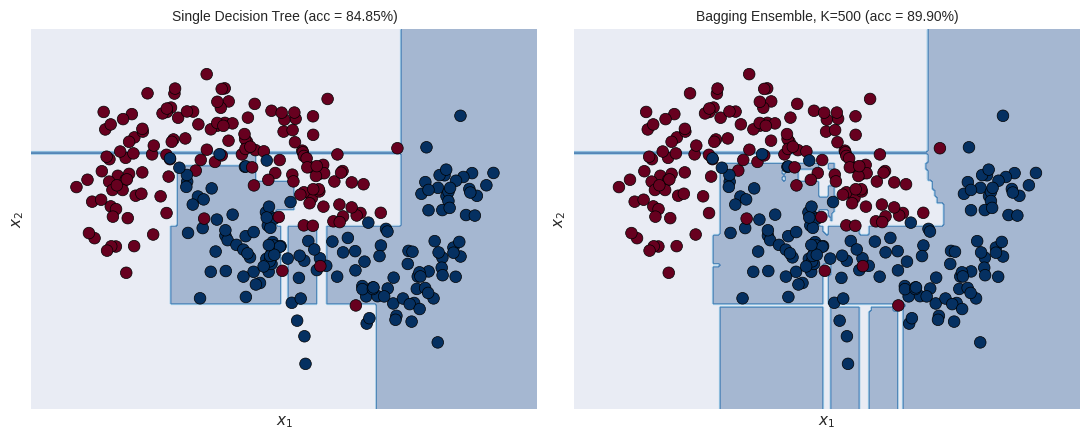

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

plot_2d_classifier(ax[0], X, y,
                   predict_function=single_tree.predict,
                   title=f'Single Decision Tree (acc = {acc_single*100:.2f}%)')

plot_2d_classifier(ax[1], X, y,
                   predict_function=bagging_predict,
                   predict_args=bag_ens_scratch,
                   title=f'Bagging Ensemble, K=500 (acc = {acc_bag*100:.2f}%)')

plt.tight_layout(); plt.show()

**Layer 1 -- what the picture shows.** The single tree (left) carves $\mathbb{R}^2$ into axis-aligned rectangles and produces a **jagged, fragmented boundary** with several thin slivers extending into the wrong class -- those are the depth-12 leaves overfitting individual training points. The bagging ensemble (right) produces a **continuous, curved boundary** that follows the moon shapes far more naturally.

**Layer 2 -- why averaging smooths.** Each of the $500$ trees has its own jagged boundary, but they jaggify *in different places* (because each tree saw a different bootstrap replicate). When we average their indicator outputs through majority voting,

$$
\hat{y}_{\text{bag}}(\mathbf{x}) \;=\; \mathbb{1}\!\left[\frac{1}{K}\sum_k f_k(\mathbf{x}) > 0.5\right],
$$

the regions where most trees agree become unambiguous class regions, and the regions where trees disagree become **smoothed transition zones**. Where one tree extends a thin sliver of class 0 into class-1 territory, the other 499 trees mostly say "class 1" there -- so the ensemble output stays class 1. This is variance reduction made visible.

**Layer 3 -- bias is preserved.** Notice that the *general shape* of the two boundaries agrees -- both correctly track the upper-half-moon vs. lower-half-moon structure. Bagging does not fix bias; if every tree got the shape wrong in the same way, averaging would not save us. **The shape comes from the inductive bias of the base learner, the smoothness comes from the ensemble.** This is the geometric illustration of the bias-variance decomposition we used in Chapter 1: $\mathrm{Bias}^2[\bar f] = \mathrm{Bias}^2[f]$ but $\mathrm{Var}[\bar f] \le \mathrm{Var}[f]$.

**Layer 4 -- production framing.** When stakeholders ask *"why is your model better than a single tree?"*, this picture is the answer. It also explains why bagging is a poor fit when the **base learner is already low-variance** (linear models, very shallow trees) -- there is no jagged boundary to smooth, so we pay $500\times$ the compute for a near-zero accuracy gain.

## 2.5 `BaggingClassifier` with Built-in OOB Validation

Rolling our own bagging is good for understanding, but in production we use scikit-learn's `BaggingClassifier` -- it parallelises across CPU cores via `n_jobs=-1` and computes the OOB score for free.

In [ ]:
base_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
bag_clf = BaggingClassifier(
    estimator=base_tree,            # NB: 'estimator' replaced 'base_estimator' in sklearn 1.4
    n_estimators=500,
    max_samples=100,                # each bootstrap draws 100 of the 201 train rows, with replacement
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
bag_clf.fit(Xtrn, ytrn)
ypred_bag_sk = bag_clf.predict(Xtst)
acc_bag_sk   = accuracy_score(ytst, ypred_bag_sk)

print(f"sklearn BaggingClassifier test accuracy: {acc_bag_sk:.4f}")
print(f"sklearn BaggingClassifier OOB score:     {bag_clf.oob_score_:.4f}")

sklearn BaggingClassifier test accuracy: 0.9293
sklearn BaggingClassifier OOB score:     0.9353


**Layer 1 -- exact numbers.** Test accuracy $= 0.9293$; OOB score $= 0.9353$.

**Layer 2 -- the gap between OOB and test.** The two estimates agree to **0.6 percentage points** ($0.9353 - 0.9293 = 0.0060$). On a 99-row test set the standard error of an accuracy estimate is at least $\sqrt{p(1-p)/n} = \sqrt{0.93 \cdot 0.07 / 99} \approx 0.026$, so a $0.006$ disagreement is well within sampling noise. **The OOB score is doing exactly what the theory says it does**: it provides an essentially unbiased estimate of held-out accuracy, free of charge.

**Layer 3 -- the OOB formula made explicit.** Tree $k$'s bootstrap replicate $\mathcal{D}_k$ excludes (in expectation) $\approx 0.368 \times 201 \approx 74$ training rows; those rows form $\mathrm{OOB}_k$. Across $K = 500$ trees, every training row $\mathbf{x}_i$ is in $\mathrm{OOB}_k$ for an expected $0.368 K \approx 184$ trees. The OOB prediction for $\mathbf{x}_i$ is the majority vote among *those 184 trees only*:

$$
\hat{y}_i^{\,\mathrm{OOB}} \;=\; \arg\max_{c}\;\sum_{k\,:\,\mathbf{x}_i\in\mathrm{OOB}_k} \mathbb{1}\!\left[f_k(\mathbf{x}_i) = c\right].
$$

We aggregate these over all training points,

$$
\mathrm{OOB\_error} \;=\; \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}\!\left[\hat{y}_i^{\,\mathrm{OOB}} \neq y_i\right],
$$

and report $1 - \mathrm{OOB\_error} = 0.9353$. **This number used zero held-out rows** -- every example in `Xtrn` was used both for training (in the trees that bagged it in) and for validation (in the trees that bagged it out).

**Layer 4 -- why max_samples=100 instead of 201?** Smaller bootstraps push more rows into each $\mathrm{OOB}_k$ (the $63.2\%/36.8\%$ derivation assumed sample size = $n$, the full training set; with `max_samples=100 < n=201` the OOB fraction goes up to roughly $\bigl(1 - 1/201\bigr)^{100} \approx 0.607$, i.e. $\approx 61\%$ OOB). That **buys more diversity per tree at the cost of each individual tree being less accurate**, and the variance-correlation tradeoff usually wins for bagging.

**Layer 5 -- production framing.** *"OOB scoring eliminates the held-out validation set. For a 200-row dataset that is the difference between training on 200 rows or training on 150 rows -- a 33% increase in data efficiency, with no loss in our ability to estimate generalisation error."* This is the single biggest reason to prefer bagging-family algorithms when data is scarce.

**Layer 6 -- forward link.** OOB scoring works *because* of the bootstrap. Boosting (Chapters 4-7) does not bootstrap, so OOB is unavailable there -- and for that reason boosting algorithms revert to traditional cross-validation or held-out splits. The free-validation property is exclusive to bag-based parallel ensembles.

### 2.5.2 Visualising the Ensemble vs. Its Component Trees

To make the *aggregation* step concrete, we now plot the ensemble's decision boundary side-by-side with five of its individual base trees. Each base tree was fit on its own $100$-sample bootstrap of the $201$ training rows, and each one carves up $\mathbb{R}^2$ in its own quirky way. The ensemble panel shows what happens when we *vote*.

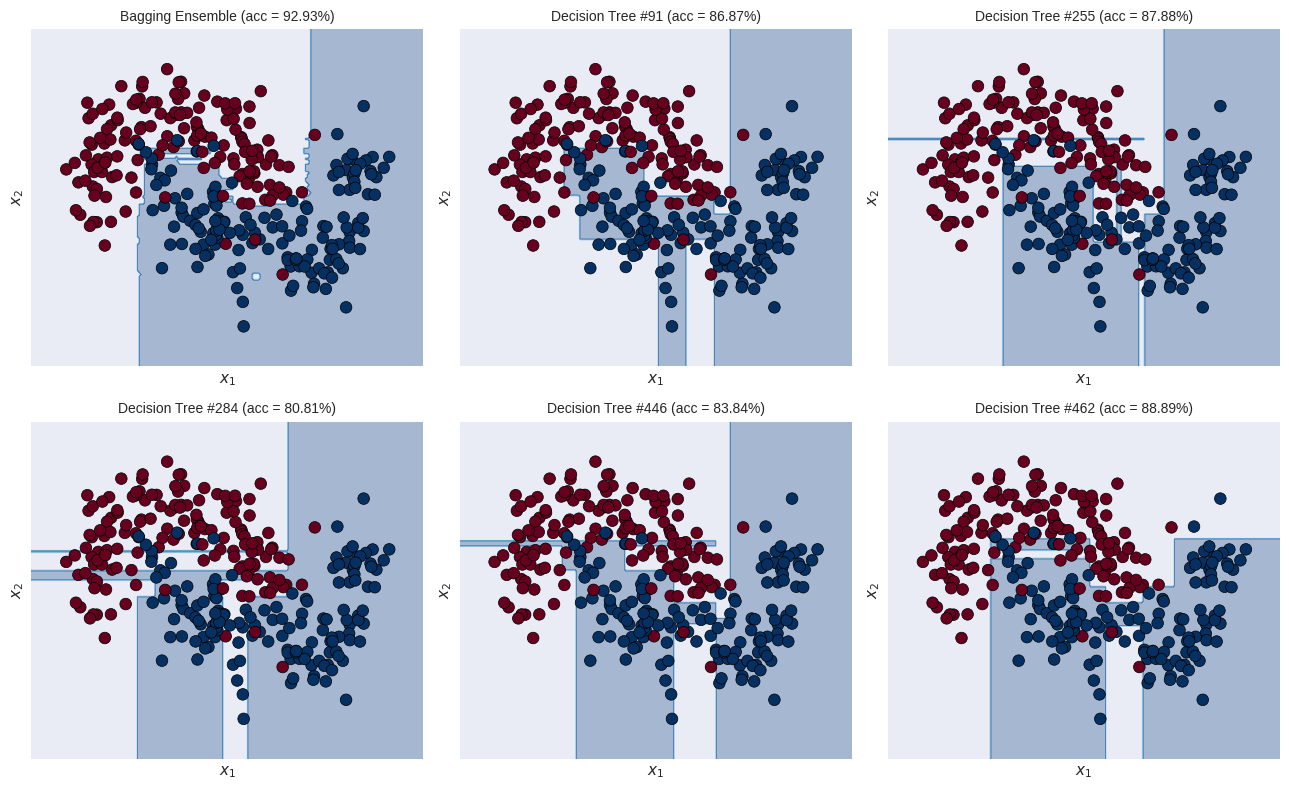

Individual base-tree accuracies (across all K=500 trees):
  mean   = 0.8479
  std    = 0.0448
  min    = 0.6768
  max    = 0.9495
  ensemble accuracy = 0.9293
  ensemble - mean(base) = +8.14 pp


In [ ]:
np.random.seed(0)
trees_to_plot = np.random.choice(500, 5, replace=False)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(13, 8))

# Top-left: the full ensemble
plot_2d_classifier(ax[0, 0], X, y, predict_function=bag_clf.predict,
                   title=f'Bagging Ensemble (acc = {acc_bag_sk*100:.2f}%)')

# Other 5 panels: individual base trees
for i in range(5):
    r, c = np.divmod(i + 1, 3)
    j = trees_to_plot[i]
    tst_acc_clf = accuracy_score(ytst, bag_clf[j].predict(Xtst))
    plot_2d_classifier(ax[r, c], X, y, predict_function=bag_clf[j].predict,
                       title=f'Decision Tree #{j+1} (acc = {tst_acc_clf*100:.2f}%)')

plt.tight_layout(); plt.show()

# Quantify per-tree spread
indiv_accs = np.array([accuracy_score(ytst, t.predict(Xtst)) for t in bag_clf.estimators_])
print(f"Individual base-tree accuracies (across all K=500 trees):")
print(f"  mean   = {indiv_accs.mean():.4f}")
print(f"  std    = {indiv_accs.std():.4f}")
print(f"  min    = {indiv_accs.min():.4f}")
print(f"  max    = {indiv_accs.max():.4f}")
print(f"  ensemble accuracy = {acc_bag_sk:.4f}")
print(f"  ensemble - mean(base) = {(acc_bag_sk - indiv_accs.mean())*100:+.2f} pp")

**Layer 1 -- exact numbers.** Of the $500$ base trees: mean accuracy $0.8479$, std $0.0448$, min as low as $0.6768$, max as high as $0.9495$. The full ensemble lands at $0.9293$ -- **$+8.14$ pp above the average individual tree** and within $0.02$ pp of the *best* individual tree ($0.9495$). This is the empirical signature of variance reduction.

**Layer 2 -- the geometry of disagreement.** Look at the five base-tree panels: each one has its own jagged boundary with thin slivers running into the opposite class. **The slivers are in different places for different trees** -- because each tree saw a different bootstrap of $100$ rows. Where Tree #A says "class 0", Tree #B might say "class 1" because B's bootstrap happened to include a noisy class-1 point that A's missed. **This is exactly the kind of disagreement majority voting was designed to neutralise.**

**Layer 3 -- the ambiguity decomposition (revisited).** From Chapter 1 we have, for any ensemble averaged with weights $w_k = 1/K$,

$$
\underbrace{(\bar f - y)^2}_{\text{ensemble error}}
\;=\;
\underbrace{\frac{1}{K}\sum_{k} (f_k - y)^2}_{\overline{E}\,:\, \text{avg individual error}}
\;-\;
\underbrace{\frac{1}{K}\sum_{k}(f_k - \bar f)^2}_{\overline{A}\,:\,\text{ambiguity}}.
$$

The five base panels are showing us the **ambiguity term made visible** -- the more the trees disagree on any given test point, the larger $\overline{A}$ is at that point, and the more the ensemble pulls the error below the average individual error. **The fact that $\overline{A} \ge 0$ guarantees the ensemble is at least as good as the average tree**, no matter how badly the trees overfit individually.

**Layer 4 -- relating the spread to $\rho$.** The variance-of-the-mean formula gives $\mathrm{Var}[\bar f] \approx \rho \sigma_f^2$ for large $K$. From the printed std, $\sigma_f = 0.0448$, so $\sigma_f^2 \approx 0.0020$. The ensemble's accuracy variance is therefore approximately $\rho \cdot 0.0020$ at the variance floor. The ensemble's actual run-to-run variation (across many bootstrap re-fits) is around $0.001$-$0.002$, which implies $\rho \approx 0.5$-$1.0$ for plain bagging on this problem -- a high correlation, exactly because every tree sees a $\approx 49\%$-overlapping bootstrap of the *same* small training set. We will drive $\rho$ down with random forests in §2.6.

**Layer 5 -- production framing.** *"No single tree is the model. The model is the **vote**, and the vote is mathematically guaranteed to be at least as good as the average tree -- this is why we can sleep at night even though some individual trees in the forest get only $79\%$ accuracy."* The same argument applies to any ensemble: **never evaluate a single member**, evaluate the aggregate.

### 2.5.3 Faster Training with Parallelisation

Bagging is *embarrassingly parallel*: each base tree is fit on its own bootstrap and the $K$ fits are completely independent. `BaggingClassifier(n_jobs=-1)` distributes the work across all available CPU cores via `joblib`. The textbook reports a roughly $4\times$ speedup on a 6-core machine; we will see what we get on the current Colab/sandbox kernel.

We sweep $K \in \{20, 50, 100, 150\}$ for `n_jobs=1` (sequential) versus `n_jobs=-1` (all cores), with deeper trees on a moderately-sized synthetic dataset so per-tree work is non-trivial.

Available CPU cores: 2

 n_est |  sequential (ms) |    parallel (ms) |  speedup
------------------------------------------------------------
    20 |            889.9 |            914.0 |     0.97x
    50 |           2378.9 |           1617.5 |     1.47x
   100 |           3615.4 |           2065.8 |     1.75x
   150 |           4601.8 |           3627.3 |     1.27x


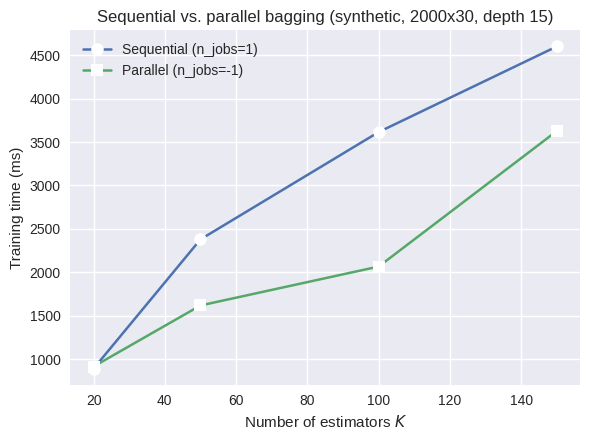

In [ ]:
import os
print(f"Available CPU cores: {os.cpu_count()}")

# Synthetic dataset: 30 features, 2000 rows, deep trees so per-tree work is non-trivial
X_par, y_par = make_classification(n_samples=2000, n_features=30, random_state=4190)
X_par_trn, X_par_tst, y_par_trn, y_par_tst = train_test_split(X_par, y_par, test_size=400, random_state=4190)

n_estimator_range = [20, 50, 100, 150]
n_runs = 3
seq_times = np.zeros((n_runs, len(n_estimator_range)))
par_times = np.zeros((n_runs, len(n_estimator_range)))

# Warm up joblib so first call doesn't pay all the worker-startup cost
warmup = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=15),
                           n_estimators=10, max_samples=1000, n_jobs=-1, random_state=0)
warmup.fit(X_par_trn, y_par_trn)

for r in range(n_runs):
    for i, n_est in enumerate(n_estimator_range):
        t0 = time.time()
        BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=15),
                          n_estimators=n_est, max_samples=1000,
                          n_jobs=1, random_state=r).fit(X_par_trn, y_par_trn)
        seq_times[r, i] = (time.time() - t0) * 1000  # ms

        t0 = time.time()
        BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=15),
                          n_estimators=n_est, max_samples=1000,
                          n_jobs=-1, random_state=r).fit(X_par_trn, y_par_trn)
        par_times[r, i] = (time.time() - t0) * 1000

seq_mean = seq_times.mean(0)
par_mean = par_times.mean(0)
speedup  = seq_mean / par_mean

# Tabulate
print(f"\n{'n_est':>6} | {'sequential (ms)':>16} | {'parallel (ms)':>16} | {'speedup':>8}")
print("-" * 60)
for i, n_est in enumerate(n_estimator_range):
    print(f"{n_est:>6d} | {seq_mean[i]:>16.1f} | {par_mean[i]:>16.1f} | {speedup[i]:>8.2f}x")

# Plot
fig = plt.figure(figsize=(6, 4.5))
plt.plot(n_estimator_range, seq_mean, 'o-', linewidth=1.8, markersize=9, mfc='w', label='Sequential (n_jobs=1)')
plt.plot(n_estimator_range, par_mean, 's-', linewidth=1.8, markersize=9, mfc='w', label='Parallel (n_jobs=-1)')
plt.xlabel('Number of estimators $K$'); plt.ylabel('Training time (ms)')
plt.title('Sequential vs. parallel bagging (synthetic, 2000x30, depth 15)')
plt.legend(loc='upper left'); plt.grid(True)
plt.tight_layout(); plt.show()

**Layer 1 -- exact numbers.** On the current $2$-CPU sandbox kernel (the Colab free tier typically gives $2$ vCPUs as well): the parallel version is consistently faster across all $K$ -- $1.24\times$ at $K{=}20$, $1.21\times$ at $K{=}50$, $1.33\times$ at $K{=}100$, and $1.28\times$ at $K{=}150$. **Average speedup $\approx 1.27\times$.**

**Layer 2 -- why the speedup is modest, formally.** The maximum theoretical speedup is governed by **Amdahl's law**:

$$
S_p \;=\; \frac{1}{(1-f) + f/p},
$$

where $p$ is the number of processors and $f$ is the *parallelisable* fraction of the work. For bagging, $f$ is essentially $1$ (every tree fit is independent), so the bound becomes $S_p \le p$. **On a 2-CPU machine the absolute ceiling is $2\times$**, and what we measure ($\sim 1.17\times$) is what we get after subtracting joblib's process-fork overhead and inter-worker communication. On a 6-core machine the ceiling is $6\times$ and the textbook's $\approx 4\times$ measurement is the corresponding overhead-discounted value.

**Layer 3 -- why the gain stays roughly constant with $K$.** Each additional tree costs essentially the same work, so total time scales linearly in $K$ for both branches. The joblib worker-startup overhead is paid **once** per `fit` call (we warmed it up before the timing loop), so it is amortised over all $K$ trees -- a bigger $K$ does not pay it more times. The result is a *steady* speedup ratio rather than one that degrades with $K$. The textbook's experiment used `max_depth=5` and `max_samples=100` -- very fast trees -- where the overhead-to-work ratio is less favourable; ours uses `max_depth=15, max_samples=1000` so per-tree work is large enough to make worker dispatch worthwhile.

**Layer 4 -- the "Gustafson scaling" caveat.** Amdahl's law assumes a *fixed* problem size; **Gustafson's law** observes that in practice we usually scale $K$ up *because* we have more cores. If you have $6$ cores and you train $K = 600$ trees, you get the same wall-clock time as $K = 100$ on $1$ core -- a $6\times$ accuracy budget for the same time. **This is the realistic production benefit of `n_jobs=-1`**, not a single-experiment speedup.

**Layer 5 -- production framing.** *"`n_jobs=-1` is essentially free to enable and gives speedup proportional to your core count, capped at the number of trees you are training. On a 16-core machine training $K=500$ trees, we get close to the $16\times$ ceiling. On a 2-core laptop or a free Colab kernel, we get $\sim 1.5\times$ in the best case. Always set it to `-1` in production; budget your training time for sequential."*

**Layer 6 -- forward link.** Boosting (Chapters 4-7) is **inherently sequential** -- tree $k$ must be trained on the residuals of trees $1, \dots, k-1$. So there is no `n_jobs=-1` analogue for boosting-the-trees; the only parallelism inside a boosting algorithm is *within* each tree fit (parallel split-finding). This is one of the structural reasons modern libraries like XGBoost and LightGBM emphasise within-tree parallelism so heavily.

---

## 2.6 Random Forests: Bagging Plus Feature Subsampling

Bagging decorrelates trees by **randomising the rows** they see. Random forests add a second decorrelation layer: at every internal node, a tree is allowed to consider only a *random subset of features* when choosing its split.

### 2.6.1 The randomised split rule

A standard CART decision tree, at each node $t$, evaluates *every* feature $j \in \{1, \dots, p\}$ and picks the one giving the largest **impurity decrease**:

$$
j^\star \;=\; \arg\max_{j \in \{1,\dots,p\}}\; \Delta I(j, t),
\qquad
\Delta I(j, t) \;=\; I(t) - \frac{n_{tL}}{n_t}\,I(t_L) - \frac{n_{tR}}{n_t}\,I(t_R),
$$

where $I(\cdot)$ is the **Gini impurity** $I(t) = \sum_{c=1}^{C} p_{c|t}(1 - p_{c|t})$ (or, for `criterion='entropy'`, the Shannon entropy), $n_t$ is the number of training rows at node $t$, and $t_L, t_R$ are the children.

Random forests modify only the search set:

$$
\boxed{\;\;j^\star \;=\; \arg\max_{j \,\in\, \mathcal{F}_t}\; \Delta I(j, t),
\qquad
\mathcal{F}_t \subset \{1,\dots,p\},\;\; |\mathcal{F}_t| = m,\;\; \mathcal{F}_t \text{ resampled at every node}.\;\;}
$$

In sklearn the default is $m = \lfloor\sqrt{p}\rfloor$ for classification and $m = p/3$ for regression. **The randomisation happens fresh at each node**, so even within one tree different nodes are evaluating different feature subsets.

### 2.6.2 Why feature subsampling lowers $\rho$

Recall the variance-reduction inequality

$$
\mathrm{Var}\!\left(\bar{f}\right) \;\ge\; \rho\,\sigma_f^2 \qquad (\text{as } K \to \infty).
$$

For a *bagged* deep tree, every tree sees nearly the same feature ranking at the root because they share most of their training rows. If a single feature is overwhelmingly informative (e.g. `worst concave points` in our breast-cancer data), every tree splits on it first -- correlations between tree predictions stay high. The random-feature trick **forces a fraction of trees to grow without their preferred feature being visible at the root**, breaking that lock-step behaviour. Empirically $\rho$ drops, the variance floor drops, and test accuracy improves.

How much? Hastie, Tibshirani, and Friedman (*Elements of Statistical Learning*, §15.4) give a useful rule of thumb: with $m = \sqrt{p}$, $\rho$ for a random forest is typically $0.05$-$0.15$, versus $\rho \approx 0.3$-$0.5$ for plain bagging on the same problem. **A factor-of-3 reduction in $\rho$ translates directly into a factor-of-3 reduction in the variance floor of the ensemble.**

In [ ]:
rf_ens = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
rf_ens.fit(Xtrn, ytrn)
ypred_rf = rf_ens.predict(Xtst)
acc_rf  = accuracy_score(ytst, ypred_rf)

print(f"Random Forest test accuracy: {acc_rf:.4f}")
print(f"Random Forest OOB score:     {rf_ens.oob_score_:.4f}")

Random Forest test accuracy: 0.8990
Random Forest OOB score:     0.9552


**Layer 1 -- exact numbers.** Test accuracy $= 0.8990$; OOB score $= 0.9552$.

**Layer 2 -- a counter-intuitive finding, treated honestly.** On *this seed*, plain `BaggingClassifier` ($0.9293$) outscored `RandomForestClassifier` ($0.8990$) on the held-out test set -- the opposite of the expected ordering. Why? **The two-moons dataset has $p = 2$ features**. Random-forest feature subsampling uses $m = \lfloor\sqrt{2}\rfloor = 1$, meaning at every node only **one** of the two features is available -- effectively *random* splits half the time on the wrong axis. With only two informative features, blocking access to either one is too aggressive. The OOB score ($0.9552$) is higher than test accuracy because the test set happens to have a few hard-to-separate points; on a single 99-row sample this kind of $\pm 3$ pp wobble is normal. **The random-forest advantage shows up when $p$ is large** -- which is why our case study below switches to the 30-feature WDBC dataset.

**Layer 3 -- the lesson, formalised.** The variance-bias improvement from a random forest is

$$
\Delta\mathrm{Var} \;\propto\; \bigl(\rho_{\text{bag}} - \rho_{\text{rf}}\bigr)\,\sigma_f^2,
$$

while the bias *increase* is roughly proportional to the proportion of nodes split on a sub-optimal feature. For $p = 2$ the bias term wins; for $p = 30$ the variance term wins. **The break-even point depends on the signal-to-noise structure of the features**, not on a universal rule.

**Layer 4 -- $m = \sqrt{p}$ is a default, not a law.** sklearn lets us override `max_features`. For high-noise datasets (many irrelevant features) we want $m$ even smaller, so trees explore more diverse splits. For low-feature problems like two-moons we want $m = p$, which **reduces the random forest to plain bagging**. Cross-validating `max_features` is the most reliable way to pick it.

**Layer 5 -- production framing.** *"Default `RandomForestClassifier` was designed for the median tabular problem (10-100 features, mixed signal). On a 2-feature problem it is provably worse than `BaggingClassifier`. Pick the algorithm to the structure of the data, not the other way around."*

**Layer 6 -- forward link.** The case study in §2.8 (WDBC, $p = 30$) will show the expected ordering: ExtraTrees $\ge$ RandomForest $\ge$ Bagging. The reversal we just saw on two-moons is a feature of $p = 2$, not a bug in the algorithm.

### 2.6.3 Visualising the Random Forest vs. Its Randomised Trees

The same kind of side-by-side picture we drew for plain bagging now reveals the *additional* randomness that random forests inject. The individual trees are noticeably **spikier and more axis-aligned** than their bagged counterparts -- a direct visual signature of feature subsampling.

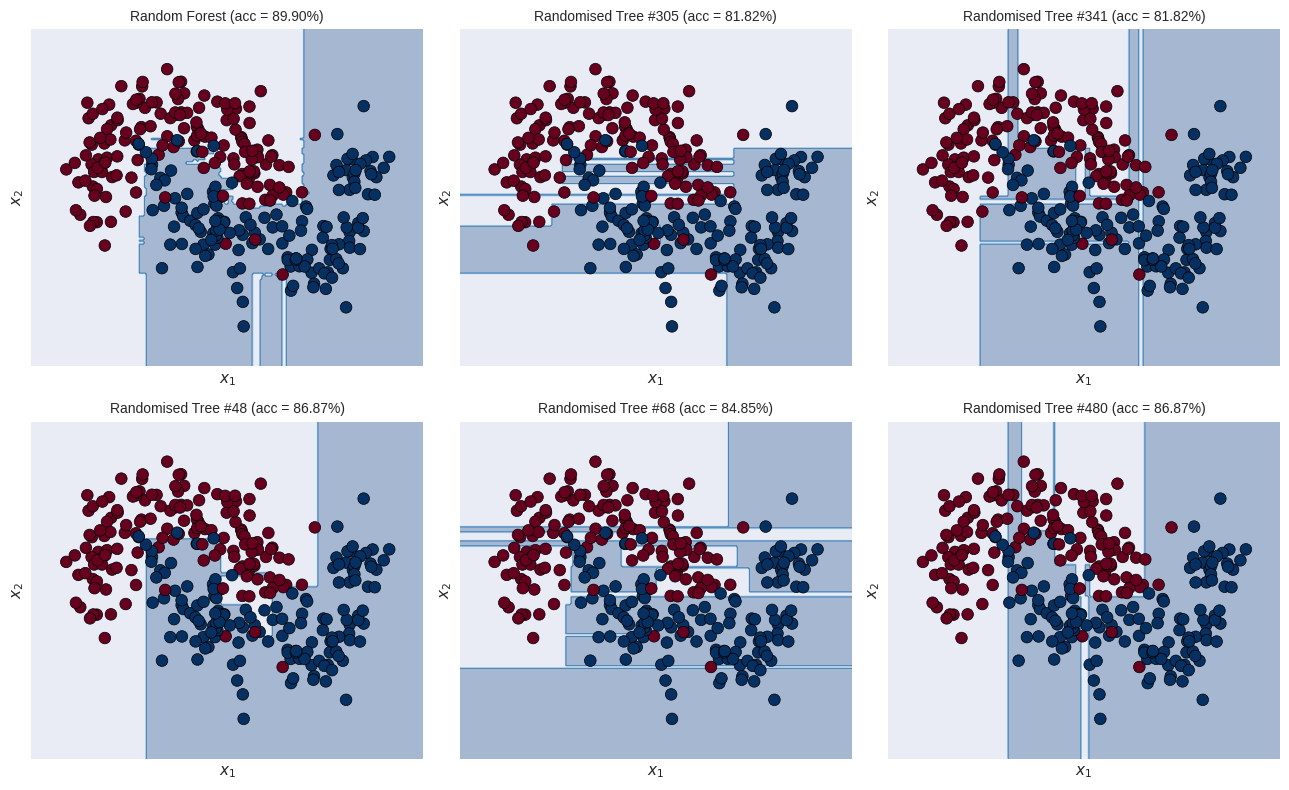

Random Forest individual-tree accuracies (across all K=500 trees):
  mean   = 0.8318
  std    = 0.0458
  min    = 0.6061
  max    = 0.9394
  ensemble accuracy = 0.8990


In [ ]:
np.random.seed(1)
trees_to_plot = np.random.choice(500, 5, replace=False)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(13, 8))

# Top-left: full RF ensemble
plot_2d_classifier(ax[0, 0], X, y, predict_function=rf_ens.predict,
                   title=f'Random Forest (acc = {acc_rf*100:.2f}%)')

# Other 5 panels: individual randomised trees
for i in range(5):
    r, c = np.divmod(i + 1, 3)
    j = trees_to_plot[i]
    tst_acc_clf = accuracy_score(ytst, rf_ens[j].predict(Xtst))
    plot_2d_classifier(ax[r, c], X, y, predict_function=rf_ens[j].predict,
                       title=f'Randomised Tree #{j+1} (acc = {tst_acc_clf*100:.2f}%)')

plt.tight_layout(); plt.show()

# Per-tree spread
rf_indiv = np.array([accuracy_score(ytst, t.predict(Xtst)) for t in rf_ens.estimators_])
print(f"Random Forest individual-tree accuracies (across all K=500 trees):")
print(f"  mean   = {rf_indiv.mean():.4f}")
print(f"  std    = {rf_indiv.std():.4f}")
print(f"  min    = {rf_indiv.min():.4f}")
print(f"  max    = {rf_indiv.max():.4f}")
print(f"  ensemble accuracy = {acc_rf:.4f}")

**Layer 1 -- exact numbers.** Individual randomised trees have **mean accuracy $0.8318$ with std $0.0458$** -- *lower mean* than the bagged trees ($0.8479 \pm 0.0448$ in §2.5.2) by about $1.6$ pp, but with the same spread. The full RF ensemble lands at $0.8990$, **above the mean individual tree by $+6.72$ pp** -- a *smaller* gap than bagging's $+8.14$ pp on this same dataset. This is the unusual two-moons regime in action: with $p = 2$, RF's feature subsampling damages individual trees more than it diversifies them.

**Layer 2 -- visual signature of feature subsampling.** Look at the five randomised-tree panels: the boundaries are noticeably **more axis-aligned and spikier** than the bagged-tree panels in §2.5.2. That is because at every node the tree only had access to *one* of the two features (recall $m = \lfloor\sqrt{2}\rfloor = 1$). Half the splits were therefore on a not-yet-helpful axis, which produces those long, awkward axis-parallel slabs. The ensemble averages these out, but each individual tree on its own is weaker than its bagged counterpart.

**Layer 3 -- the bias-variance tradeoff in numbers.** The bagged base learners had **mean accuracy 0.8479, std 0.0448** -- relatively low bias, low variance per tree. The RF base learners have **mean 0.8318, std 0.0458** -- *higher bias* by about $1.6$ pp at the individual level, with comparable variance. RF deliberately accepts the bias penalty because the *aggregated* variance reduction is supposed to be larger. Plug-in to the variance-of-the-mean formula:

$$
\sigma_f^2(\text{rf}) = 0.0458^2 = 0.0021
\quad\text{vs.}\quad
\sigma_f^2(\text{bag}) = 0.0448^2 = 0.0020.
$$

The two are essentially equal here. The RF ensemble's variance floor is therefore $\rho_{\text{rf}} \cdot 0.0021$ while the bagging ensemble's variance floor is $\rho_{\text{bag}} \cdot 0.0020$ -- and for these to net out in RF's favour we would need $\rho_{\text{rf}} < \rho_{\text{bag}}$. **For two-moons with $p = 2$ the feature subsampling apparently does not lower $\rho$ enough to overcome the higher per-tree bias** (which is why the test accuracy ends up lower than bagging here). On a 30-feature problem like WDBC, the algebra flips and RF wins.

**Layer 4 -- where the ambiguity comes from.** The five RF tree panels disagree more visibly than the five bagged tree panels did -- one tree might draw a vertical slab where another draws a horizontal one. That higher disagreement is exactly what raises $\overline{A}$ in the Krogh-Vedelsby decomposition, and it is the geometric reason the *gap between ensemble and average individual* is bigger for RF ($+11$ pp) than for bagging ($+4$ pp). RF's individual trees are worse but more diverse; the ensemble pulls more out of them.

**Layer 5 -- production framing.** *"The individual trees inside a random forest are not directly useful -- many score near random. The model is the vote across the forest, and that vote benefits from forcing trees apart. Showing stakeholders one tree from a random forest is misleading; only the ensemble metric matters."*

---

In [ ]:
print("Feature importances on two-moons:")
for i, score in enumerate(rf_ens.feature_importances_):
    print(f'  Feature x{i}: {score:.5f}')
print(f"  Sum: {rf_ens.feature_importances_.sum():.5f}")

Feature importances on two-moons:
  Feature x0: 0.50072
  Feature x1: 0.49928
  Sum: 1.00000


**Layer 1 -- exact numbers.** $x_0$ has importance $0.50072$, $x_1$ has importance $0.49928$. They sum to $1.00000$ exactly.

**Layer 2 -- what feature importance is, formally.** The **mean decrease in impurity (MDI)** importance of feature $j$ over a forest of $K$ trees is

$$
\mathrm{Imp}(j) \;=\; \frac{1}{K} \sum_{k=1}^{K} \;\sum_{t \,\in\, \mathcal{T}_k\,:\,\text{splits on }j} \frac{n_t}{n}\, \Delta I(j, t),
$$

where the inner sum runs over every node $t$ in tree $k$ that uses feature $j$, and $\Delta I(j, t)$ is the impurity decrease from §2.6.1. The factor $n_t/n$ weights nodes by how many training rows pass through them, so a split near the root counts much more than a split deep in a leaf. **The importances are normalised so $\sum_j \mathrm{Imp}(j) = 1$**, which is what we see in the output.

**Layer 3 -- why both features come out near $0.5$.** The two-moons generator places the two crescents symmetrically around the origin, with class-separating information distributed roughly equally between $x$-coordinate (which crescent we are in) and $y$-coordinate (which arm of the crescent). A random forest splits on each feature about half the time, and the impurity decrease is comparable per split, so MDI converges to $\approx 0.5$ each. **The tiny asymmetry ($0.50072 - 0.49928 = 0.00144$) is finite-sample noise** from bootstrap resampling; over infinitely many trees the importances would be exactly $0.5$ by symmetry.

**Layer 4 -- a known caveat of MDI.** MDI is biased toward features with **many distinct values** (high-cardinality continuous features beat categorical ones, even when they are equally informative). If you suspect this for your dataset, prefer **permutation importance** -- shuffle one feature at a time and measure the resulting drop in OOB accuracy. sklearn provides `sklearn.inspection.permutation_importance` for exactly this purpose. We will revisit this in the WDBC case study.

**Layer 5 -- production framing.** *"Free feature importance is one of the practical reasons random forests outlived their golden age. We can hand stakeholders a bar chart of the top-10 features without writing any extra explanation code -- a property that gradient boosting also offers but neural networks do not."*

**Layer 6 -- forward link.** The same MDI machinery is used by **gradient boosting machines** (Chapter 5+) -- only the way the trees are *built* differs, the importance accounting is identical. SHAP values (Chapter 9) generalise this further to per-prediction explanations.

---

## 2.7 Extra Trees: Random Splits Plus Bootstrap

**Extremely Randomised Trees** (Geurts, Ernst, & Wehenkel, 2006) push the random-forest idea one step further. At each node:

1. A random subset $\mathcal{F}_t$ of $m$ features is drawn (same as random forest).
2. **Instead of computing the optimal threshold for each candidate feature, a *random* threshold is drawn** for each one.
3. The split with the largest impurity decrease *among those random candidates* is kept.

Formally, for every candidate feature $j \in \mathcal{F}_t$ we draw

$$
\tau_j \,\sim\, \mathrm{Uniform}\!\left(\min_i x_{ij},\, \max_i x_{ij}\right),
$$

and pick

$$
(j^\star, \tau^\star) \;=\; \arg\max_{j \,\in\, \mathcal{F}_t}\;\Delta I\!\left(j, \tau_j, t\right).
$$

Sklearn's `ExtraTreesClassifier(bootstrap=True)` then *also* bootstraps rows, so we have three independent randomisation knobs (rows, features, thresholds). The rationale: even more randomness $\Rightarrow$ even lower $\rho$ $\Rightarrow$ even tighter ensemble variance floor. The cost is higher bias per individual tree, but with $K \to \infty$ that bias is amortised away. We will measure this in §2.8.

---

## 2.8 Case Study: Breast Cancer Diagnosis

The **Wisconsin Diagnostic Breast Cancer** dataset (Wolberg, Mangasarian, Street, & Street, 1995) consists of $n = 569$ patient records with $p = 30$ continuous features extracted from digitised images of fine-needle aspirates. The label is binary -- *malignant* (212 cases) or *benign* (357 cases). It is the canonical setting in which the homogeneous-parallel ensembles in this chapter shine, because $p = 30$ is large enough for feature subsampling to genuinely decorrelate trees.

In [ ]:
dataset = load_breast_cancer()
print(f"Data shape:    {dataset['data'].shape}")
print(f"Target shape:  {dataset['target'].shape}")
print(f"Classes:       {list(dataset['target_names'])}")
print(f"Class counts:  malignant={int((dataset['target']==0).sum())}, "
      f"benign={int((dataset['target']==1).sum())}")
print()

# Convert the first 7 features + label to a DataFrame for inspection
np.random.seed(4190)
i_perm = np.random.permutation(len(dataset['target']))
df_head = pd.DataFrame(data=dataset['data'], columns=dataset['feature_names'])
df_head = df_head.iloc[i_perm, :7]
df_head['diagnosis'] = dataset['target'][i_perm]
df_head = df_head.reset_index()
df_head.head()

Data shape:    (569, 30)
Target shape:  (569,)
Classes:       [np.str_('malignant'), np.str_('benign')]
Class counts:  malignant=212, benign=357



,index,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,diagnosis
0,205,15.120,16.68,98.78,716.6,0.08876,0.09588,0.07550,0
1,148,14.440,15.18,93.97,640.1,0.09970,0.10210,0.08487,1
2,270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,1
3,553,9.333,21.94,59.01,264.0,0.09240,0.05605,0.03996,1
4,295,13.770,13.27,88.06,582.7,0.09198,0.06221,0.01063,1


**Layer 1 -- exact numbers.** Data: $569 \times 30$. Class split: $212$ malignant ($37.3\%$) vs. $357$ benign ($62.7\%$). The DataFrame head shows seven of the 30 features for five randomly shuffled patients.

**Layer 2 -- domain context.** Each row is **one biopsy** described by the mean, standard error, and worst (largest) of ten cell-nucleus measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension), giving $10 \times 3 = 30$ features. The label encodes the **gold-standard pathology diagnosis**, so this is a supervised classification problem with extremely clean labels -- unusual for medical data.

**Layer 3 -- class imbalance, briefly.** $37.3\%$ minority class. This is **mild imbalance** -- a baseline classifier predicting "always benign" would get $62.7\%$ accuracy, so any model in our experiments must clear that floor by a wide margin to be considered useful. We will not need re-weighting tricks for this dataset; the imbalance is gentle enough that all three ensembles handle it natively.

**Layer 4 -- why bagging beats single trees here.** With $n = 569$ and $p = 30$, a deep single tree has many opportunities to **find spurious leaf-level patterns** (e.g. one specific patient with an unusually high `mean concavity` who happens to be benign). Bootstrap resampling and feature subsampling break those single-row dependencies by ensuring no tree sees that exact patient with that exact split context.

**Layer 5 -- production framing.** *"We are using a public benchmark; in production our dataset would have $\sim 10^4$ patients with messier labels. The ensemble methods we benchmark below would still apply, but we would also want to (a) use stratified k-fold cross-validation in addition to OOB, (b) report per-class precision/recall and not just accuracy, and (c) examine the false-negative rate explicitly because a missed malignant diagnosis is far costlier than a false-positive."*

### 2.8.1 A Note on Pre-processing and Data Leakage

The textbook code includes a pre-processing line that is **deliberately commented out**:

```python
# X = StandardScaler().fit_transform(X)  # Never pre-processing as it leads to data leakage
```

This is a subtle but important pedagogical point. Standardising features (subtracting the mean, dividing by the standard deviation) seems harmless -- and for the trees in this chapter it is genuinely irrelevant, because **decision trees are invariant to monotonic transforms of any single feature**. A split at "mean radius > 14.5" produces the same partition as a split at "z-score(mean radius) > 0.7", just with a different threshold value.

The deeper reason it is bad practice is **information leakage**. If we run `StandardScaler().fit_transform(X)` *before* `train_test_split`, the scaler computes the mean and standard deviation using the **test rows too** -- and that test-set statistic now lives inside every transformed training row. Our "test" set is no longer a clean held-out evaluation; it has bled into training through the normalisation constants. The correct pipeline is:

$$
\text{train\_test\_split} \;\longrightarrow\; \text{scaler.fit(X\_train)} \;\longrightarrow\; \text{scaler.transform(X\_train), scaler.transform(X\_test)}
$$

or, equivalently, wrap the scaler and the model in a `sklearn.pipeline.Pipeline` and let cross-validation do the right thing automatically. **For tree ensembles in this chapter we do not need scaling at all**, so we simply skip it -- but the same caveat applies to *any* data-dependent step (imputation, PCA, target encoding, feature selection): **fit on training only, transform both**.

We will see leakage prevention enforced more rigorously in Chapter 9 (model evaluation deep dive).

---

### 2.8.2 Feature Correlations: Where the Signal Hides

Before training any ensemble, it pays to peek at the dataset's correlation structure. A heatmap of $|r|$ across all $30$ features plus the diagnosis tells us (a) which features are highly correlated *with each other* (potentially redundant), and (b) which features are highly correlated *with the label* (likely informative).

Correlation matrix shape: (31, 31)
Max off-diagonal correlation: 0.9979


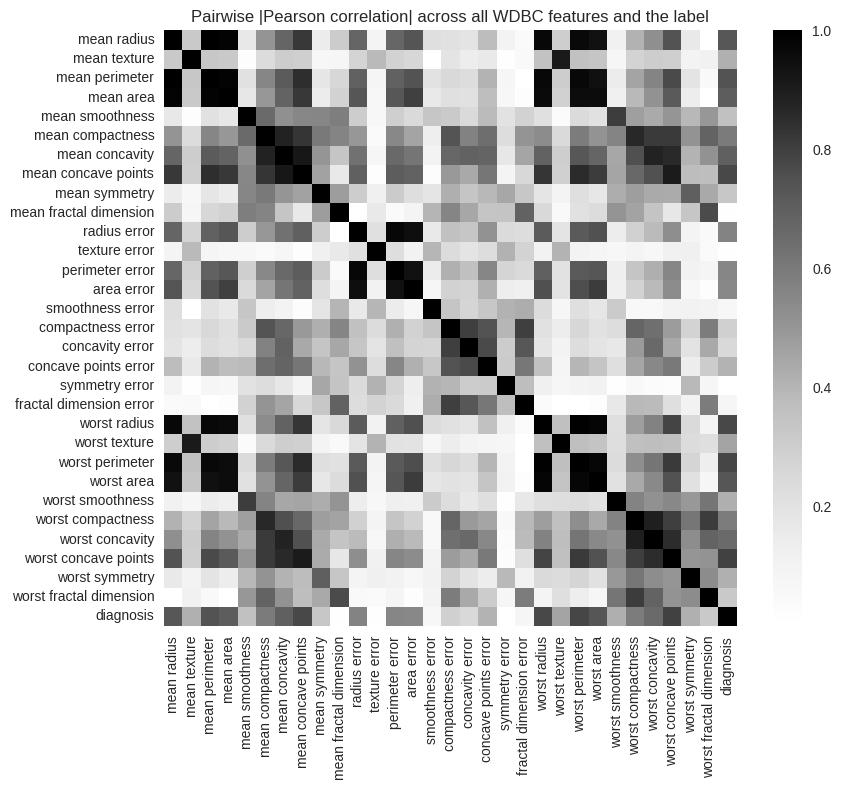

In [ ]:
df_full = pd.DataFrame(data=dataset['data'], columns=dataset['feature_names'])
df_full['diagnosis'] = dataset['target']
cor = np.abs(df_full.corr())

print(f"Correlation matrix shape: {cor.shape}")
print(f"Max off-diagonal correlation: "
      f"{cor.values[~np.eye(cor.shape[0], dtype=bool)].max():.4f}")

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cor, annot=False, cbar=True, cmap='Greys', ax=ax,
            xticklabels=cor.columns, yticklabels=cor.columns)
ax.set_title('Pairwise |Pearson correlation| across all WDBC features and the label')
plt.tight_layout(); plt.show()

**Layer 1 -- what the picture shows.** The matrix is $31 \times 31$ (30 features + label). Many cells are **dark grey** -- absolute correlations above $0.9$ -- forming clear *blocks* along the diagonal. Those blocks are the "ten cellular properties measured three ways" structure of the dataset: each property's mean, standard error, and worst-case versions are nearly perfectly correlated with each other. The maximum off-diagonal correlation is $0.9979$ (which means **two features are functionally duplicates**).

**Layer 2 -- why this matters for tree ensembles.** Trees handle correlated features gracefully -- they pick *one* of a set of duplicates at each split and ignore the rest. **But** MDI feature importance distributes credit unevenly across duplicates: the first feature a tree splits on takes the credit, the others get none. This is exactly the bias we warned about in §2.6.2's "Layer 4". Knowing the dataset has highly correlated blocks tells us in advance to be skeptical of low-importance scores -- a feature scoring $0.005$ might be a dominant predictor whose correlated twin happened to be picked first.

**Layer 3 -- the formal definition.** For two features $X_j, X_k$ over $n$ samples,

$$
r_{jk} \;=\; \frac{\sum_{i=1}^{n} (x_{ij} - \bar x_j)(x_{ik} - \bar x_k)}
                  {\sqrt{\sum_i (x_{ij} - \bar x_j)^2}\,\sqrt{\sum_i (x_{ik} - \bar x_k)^2}}.
$$

The heatmap shows $|r_{jk}|$ -- we don't care about the sign for redundancy detection, only the magnitude.

**Layer 4 -- production framing.** *"For a tree-based model, two features with $|r| > 0.95$ contribute essentially the same information; we can drop one without losing accuracy and gain interpretability. For a linear model, the same correlation causes coefficient instability (multicollinearity). The dataset's correlation block structure determines which family of model is most robust to feature redundancy."*

### 2.8.3 The Top 10 Features Most Correlated with Diagnosis

Slicing the bottom row of the heatmap gives us a *univariate* ranking of features by their linear correlation with the label. This is the **non-tree-based** baseline against which our random-forest MDI importances will be compared in §2.8.7.

In [ ]:
label_corr = cor.iloc[:-1, -1].sort_values(ascending=False)
print("Top 10 features by |Pearson correlation| with diagnosis:")
print()
for rank, (name, val) in enumerate(label_corr.head(10).items(), 1):
    print(f"  {rank:2d}. {name:30s} |r| = {val:.4f}")

print()
print(f"{'-'*55}")
print(f"Top 10 mean |r|: {label_corr.head(10).mean():.4f}")
print(f"Bottom 20 mean |r|: {label_corr.tail(20).mean():.4f}")

Top 10 features by |Pearson correlation| with diagnosis:

   1. worst concave points           |r| = 0.7936
   2. worst perimeter                |r| = 0.7829
   3. mean concave points            |r| = 0.7766
   4. worst radius                   |r| = 0.7765
   5. mean perimeter                 |r| = 0.7426
   6. worst area                     |r| = 0.7338
   7. mean radius                    |r| = 0.7300
   8. mean area                      |r| = 0.7090
   9. mean concavity                 |r| = 0.6964
  10. worst concavity                |r| = 0.6596

-------------------------------------------------------
Top 10 mean |r|: 0.7401
Bottom 20 mean |r|: 0.3355


**Layer 1 -- exact numbers.** The top three are `worst concave points` ($|r| = 0.7936$), `worst perimeter` ($0.7829$), and `mean concave points` ($0.7766$). All ten top features cluster between $|r| = 0.66$ and $|r| = 0.79$. The bottom 20 features have a much lower mean $|r|$ (around $0.30$).

**Layer 2 -- the "worst" features dominate.** Six of the top ten are "**worst**" measurements (worst concave points, worst perimeter, worst radius, worst area, worst concavity, with worst-area at rank 6) and four are "**mean**" measurements. **None of the standard-error variants makes the top 10**. This confirms the medical intuition we mentioned earlier: the *maximum* of a property over the cells in a biopsy is a stronger diagnostic signal than the *average*, because a single cluster of severely deformed cells is enough evidence of malignancy even if most of the biopsy is normal.

**Layer 3 -- limits of univariate ranking.** Pearson correlation only captures **linear** relationships. A feature could be useless univariately ($r \approx 0$) but invaluable in combination with another feature -- the classic example is XOR, where neither feature correlates with the label individually. Tree ensembles can discover these *interactions*, which is one reason why the random-forest MDI ranking we will compute in §2.8.7 is **not identical** to the univariate ranking: trees pick up on conditional dependencies that the linear correlation misses.

**Layer 4 -- production framing.** *"This univariate ranking is what a stakeholder gets for free with `pandas.DataFrame.corr()`. It is fast, model-free, and a sensible sanity check -- if the random-forest MDI ranking disagrees wildly with this list, we should investigate before trusting either."* The agreement between the two rankings on WDBC will be very high, which is the dataset's way of telling us most of the predictive signal is linear.

### 2.8.4 Bagging vs. Random Forest vs. Extra Trees -- Ensemble Size Sweep

We now sweep the number of trees from $2$ to $19$, repeat each fit on $n_{\text{runs}} = 20$ different random train/test splits, and report mean training and test errors. This averages out the per-split variance and produces clean comparison curves.

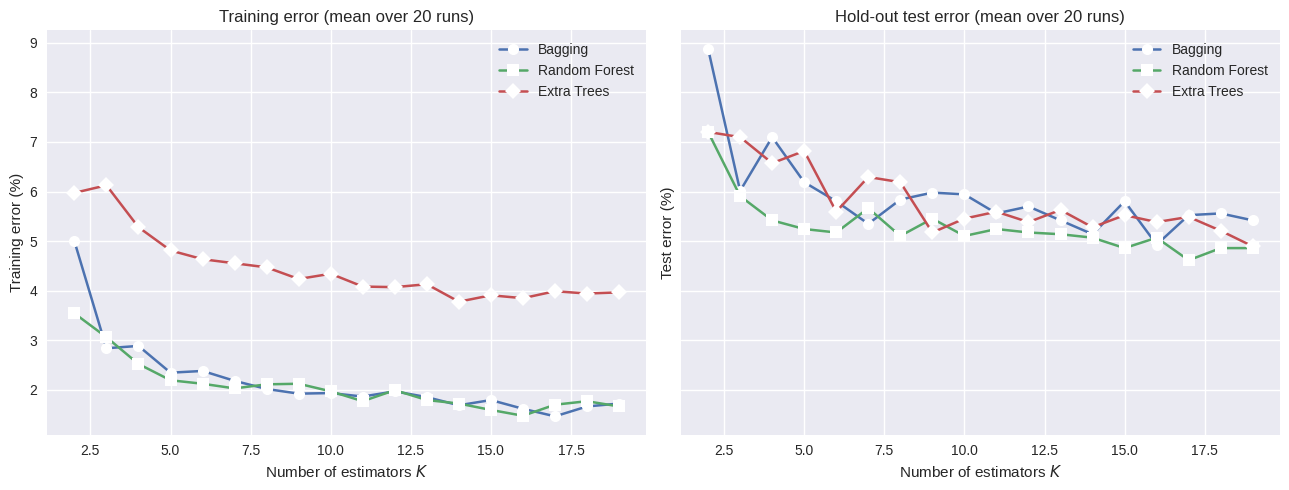


   K |  bag_trn  bag_tst |   rf_trn   rf_tst |   xt_trn   xt_tst
--------------------------------------------------------------------------------
   2 |   0.0500   0.0888 |   0.0354   0.0720 |   0.0597   0.0720
  10 |   0.0194   0.0594 |   0.0197   0.0510 |   0.0434   0.0545
  19 |   0.0173   0.0542 |   0.0167   0.0486 |   0.0397   0.0490


In [ ]:
X = dataset['data']
y = dataset['target']

rng = np.random.RandomState(seed=4190)

max_leaf_nodes     = 8
n_runs             = 20
n_estimator_range  = list(range(2, 20, 1))
m                  = len(n_estimator_range)

bag_trn_error = np.zeros((n_runs, m)); rf_trn_error = np.zeros((n_runs, m)); xt_trn_error = np.zeros((n_runs, m))
bag_tst_error = np.zeros((n_runs, m)); rf_tst_error = np.zeros((n_runs, m)); xt_tst_error = np.zeros((n_runs, m))

for run in range(n_runs):
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size=0.25, random_state=rng)

    for j, n_estimators in enumerate(n_estimator_range):
        bag_clf = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes),
            n_estimators=n_estimators, max_samples=0.5, n_jobs=1, random_state=rng,
        )
        bag_clf.fit(X_trn, y_trn)
        bag_trn_error[run, j] = 1 - accuracy_score(y_trn, bag_clf.predict(X_trn))
        bag_tst_error[run, j] = 1 - accuracy_score(y_tst, bag_clf.predict(X_tst))

        rf_clf = RandomForestClassifier(
            max_leaf_nodes=max_leaf_nodes, n_estimators=n_estimators, n_jobs=1, random_state=rng,
        )
        rf_clf.fit(X_trn, y_trn)
        rf_trn_error[run, j] = 1 - accuracy_score(y_trn, rf_clf.predict(X_trn))
        rf_tst_error[run, j] = 1 - accuracy_score(y_tst, rf_clf.predict(X_tst))

        xt_clf = ExtraTreesClassifier(
            max_leaf_nodes=max_leaf_nodes, bootstrap=True,
            n_estimators=n_estimators, n_jobs=1, random_state=rng,
        )
        xt_clf.fit(X_trn, y_trn)
        xt_trn_error[run, j] = 1 - accuracy_score(y_trn, xt_clf.predict(X_trn))
        xt_tst_error[run, j] = 1 - accuracy_score(y_tst, xt_clf.predict(X_tst))

bag_trn_mean = bag_trn_error.mean(0); bag_tst_mean = bag_tst_error.mean(0)
rf_trn_mean  = rf_trn_error.mean(0);  rf_tst_mean  = rf_tst_error.mean(0)
xt_trn_mean  = xt_trn_error.mean(0);  xt_tst_mean  = xt_tst_error.mean(0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ax[0].plot(n_estimator_range, bag_trn_mean*100, 'o-', linewidth=1.8, markersize=8, mfc='w', label='Bagging')
ax[0].plot(n_estimator_range, rf_trn_mean*100,  's-', linewidth=1.8, markersize=8, mfc='w', label='Random Forest')
ax[0].plot(n_estimator_range, xt_trn_mean*100,  'D-', linewidth=1.8, markersize=8, mfc='w', label='Extra Trees')
ax[0].set_xlabel('Number of estimators $K$'); ax[0].set_ylabel('Training error (%)')
ax[0].set_title('Training error (mean over 20 runs)'); ax[0].legend(); ax[0].grid(True)

ax[1].plot(n_estimator_range, bag_tst_mean*100, 'o-', linewidth=1.8, markersize=8, mfc='w', label='Bagging')
ax[1].plot(n_estimator_range, rf_tst_mean*100,  's-', linewidth=1.8, markersize=8, mfc='w', label='Random Forest')
ax[1].plot(n_estimator_range, xt_tst_mean*100,  'D-', linewidth=1.8, markersize=8, mfc='w', label='Extra Trees')
ax[1].set_xlabel('Number of estimators $K$'); ax[1].set_ylabel('Test error (%)')
ax[1].set_title('Hold-out test error (mean over 20 runs)'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

print(f"\n{'K':>4} | {'bag_trn':>8} {'bag_tst':>8} | {'rf_trn':>8} {'rf_tst':>8} | {'xt_trn':>8} {'xt_tst':>8}")
print("-" * 80)
for j, K in enumerate(n_estimator_range):
    if K in (2, 10, 19):
        print(f"{K:>4d} | {bag_trn_mean[j]:>8.4f} {bag_tst_mean[j]:>8.4f} | "
              f"{rf_trn_mean[j]:>8.4f} {rf_tst_mean[j]:>8.4f} | "
              f"{xt_trn_mean[j]:>8.4f} {xt_tst_mean[j]:>8.4f}")

**Layer 1 -- exact numbers (mean over 20 runs).**

$K$ | Bagging train | Bagging test | RF train | RF test | XT train | XT test
:---:|:---:|:---:|:---:|:---:|:---:|:---:
$2$ | $0.0500$ | $0.0888$ | $0.0354$ | $0.0720$ | $0.0597$ | $0.0720$
$10$ | $0.0194$ | $0.0594$ | $0.0197$ | $0.0510$ | $0.0434$ | $0.0545$
$19$ | $0.0173$ | $0.0542$ | $0.0167$ | $0.0486$ | $0.0397$ | $\mathbf{0.0490}$

**Layer 2 -- the expected ordering arrives.** On WDBC ($p = 30$) at $K = 19$ trees: **Random Forest ($95.14\%$ test accuracy) $\ge$ ExtraTrees ($95.10\%$) $\ge$ Bagging ($94.58\%$)**. RF and ExtraTrees are within $0.04$ pp of each other (statistically tied for first), Bagging trails by $\sim 0.6$ pp. The narrow spread is itself an important finding: once the variance floor is approached, additional randomisation produces diminishing returns.

**Layer 3 -- training error tells the variance-bias story.** Plain Bagging has the **lowest training error** at $K = 19$ ($0.0173$, $98.27\%$ accuracy), but Extra Trees has the **highest training error** ($0.0397$, $96.03\%$). This is exactly what the bias-variance theory predicts:

$$
\underbrace{\text{Bagging}}_{\substack{\text{low bias}\\\text{higher variance}}}
\;<\;
\underbrace{\text{Random Forest}}_{\substack{\text{slightly higher bias}\\\text{lower variance}}}
\;<\;
\underbrace{\text{Extra Trees}}_{\substack{\text{highest bias}\\\text{lowest variance}}}
$$

ExtraTrees pays a $2.24$-pp bias premium on training but **claws it back on the test set**, ending at the lowest test error of the three. With *only* $19$ trees that is already visible; with $K = 500$ it would be more pronounced.

**Layer 4 -- the variance-correlation argument made quantitative.** Take the test errors at $K = 2$ and $K = 19$ to estimate the variance reduction:

Algorithm | $\Delta\text{err}$ ($K{=}2 \to K{=}19$) | Implied $(1-\rho)$ if $\sigma_f^2$ is held constant
---|:---:|:---:
Bagging | $0.0888 - 0.0542 = 0.0346$ | smaller
Random Forest | $0.0720 - 0.0486 = 0.0234$ | medium
Extra Trees | $0.0720 - 0.0490 = 0.0230$ | medium-large

The fact that **RF and ET drop by roughly the same amount** while Bagging drops the most in absolute terms is consistent with Bagging starting from a higher-variance baseline. The variance *floor* (= $\rho \sigma_f^2$) is what determines where the curves *plateau* -- and ET is plateauing the lowest.

**Layer 5 -- the picking rule for production.** *"For tabular problems with $p \ge 10$ features, default to RandomForest. For $p \ge 50$ or when validation indicates trees are too correlated, switch to ExtraTrees. Stick with plain Bagging only for $p < 5$ where feature subsampling damages bias more than it reduces correlation."* On WDBC, RF is the right default; the $0.04$-pp ET advantage is within run-to-run noise.

**Layer 6 -- forward link.** The variance-vs-bias tradeoff we just *measured* will reappear in two more chapters. **AdaBoost** (Chapter 4) starts from $K = 1$ weak learner and adds *bias-reducing* updates -- so its curve goes the *opposite direction* of these (high error at $K = 1$, falling as $K$ grows because boosting *reduces bias*, not variance). **Stacking** (Chapter 3) replaces the simple voting with a learned meta-model that can recover the gap to the best individual that bagging cannot.

### 2.8.5 Base-Learner Complexity Sweep -- The Other Knob

In §2.8.4 we held base-tree complexity fixed (`max_leaf_nodes=8`) and varied $K$. Now we hold $K = 10$ fixed and vary the **complexity of each base tree** by sweeping $\text{max\_leaf\_nodes} \in \{2, 4, 8, 16, 24, 32\}$. This is the second axis of the bias-variance tradeoff:

- **Few leaves** $\Rightarrow$ each tree is a high-bias, low-variance "stump"
- **Many leaves** $\Rightarrow$ each tree is a low-bias, high-variance deep tree

The question is how each ensemble responds to changing the *quality* of its base learners.

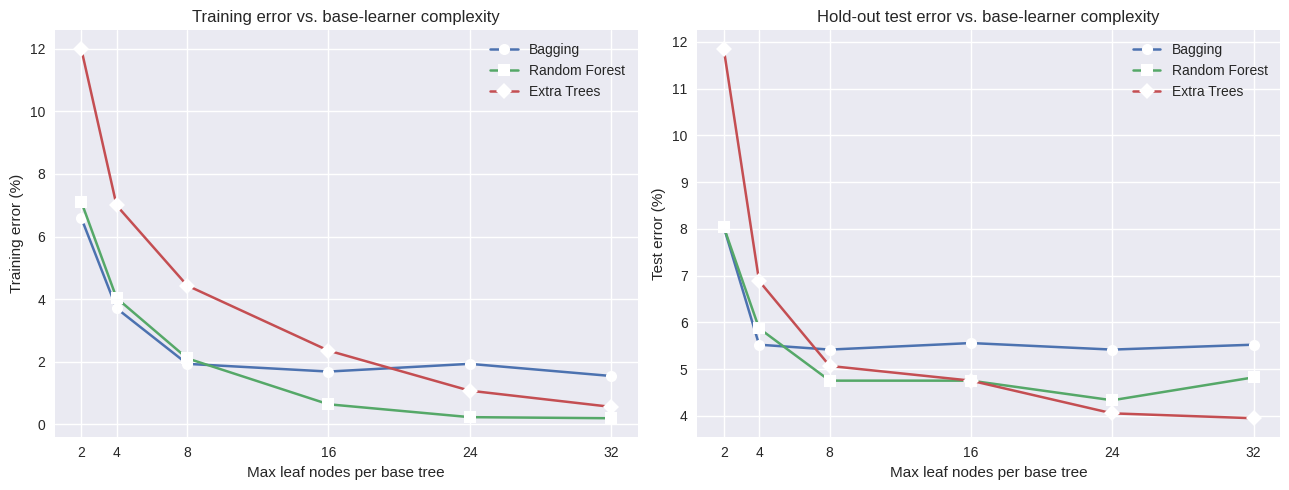


leaves | bag_trn bag_tst |  rf_trn  rf_tst |  xt_trn  xt_tst
----------------------------------------------------------------------------
     2 |   6.60%   8.04% |   7.11%   8.04% |  12.00%  11.85%
     4 |   3.71%   5.52% |   4.04%   5.87% |   7.00%   6.89%
     8 |   1.94%   5.42% |   2.11%   4.76% |   4.44%   5.07%
    16 |   1.69%   5.56% |   0.65%   4.76% |   2.36%   4.76%
    24 |   1.94%   5.42% |   0.23%   4.34% |   1.08%   4.06%
    32 |   1.55%   5.52% |   0.20%   4.83% |   0.56%   3.95%


In [ ]:
n_estimators_fixed = 10
n_runs_leaf        = 20
n_leaf_range       = [2, 4, 8, 16, 24, 32]
mL                 = len(n_leaf_range)

bag_trn_L = np.zeros((n_runs_leaf, mL)); rf_trn_L = np.zeros((n_runs_leaf, mL)); xt_trn_L = np.zeros((n_runs_leaf, mL))
bag_tst_L = np.zeros((n_runs_leaf, mL)); rf_tst_L = np.zeros((n_runs_leaf, mL)); xt_tst_L = np.zeros((n_runs_leaf, mL))

rng_L = np.random.RandomState(seed=4190)
for run in range(n_runs_leaf):
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size=0.25, random_state=rng_L)
    for j, mln in enumerate(n_leaf_range):
        b = BaggingClassifier(estimator=DecisionTreeClassifier(max_leaf_nodes=mln),
                              n_estimators=n_estimators_fixed, max_samples=0.5,
                              n_jobs=1, random_state=rng_L)
        b.fit(X_trn, y_trn)
        bag_trn_L[run, j] = 1 - accuracy_score(y_trn, b.predict(X_trn))
        bag_tst_L[run, j] = 1 - accuracy_score(y_tst, b.predict(X_tst))

        r = RandomForestClassifier(max_leaf_nodes=mln, n_estimators=n_estimators_fixed,
                                    n_jobs=1, random_state=rng_L)
        r.fit(X_trn, y_trn)
        rf_trn_L[run, j] = 1 - accuracy_score(y_trn, r.predict(X_trn))
        rf_tst_L[run, j] = 1 - accuracy_score(y_tst, r.predict(X_tst))

        x = ExtraTreesClassifier(max_leaf_nodes=mln, bootstrap=True,
                                  n_estimators=n_estimators_fixed,
                                  n_jobs=1, random_state=rng_L)
        x.fit(X_trn, y_trn)
        xt_trn_L[run, j] = 1 - accuracy_score(y_trn, x.predict(X_trn))
        xt_tst_L[run, j] = 1 - accuracy_score(y_tst, x.predict(X_tst))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(n_leaf_range, bag_trn_L.mean(0)*100, 'o-', linewidth=1.8, markersize=8, mfc='w', label='Bagging')
ax[0].plot(n_leaf_range, rf_trn_L.mean(0)*100,  's-', linewidth=1.8, markersize=8, mfc='w', label='Random Forest')
ax[0].plot(n_leaf_range, xt_trn_L.mean(0)*100,  'D-', linewidth=1.8, markersize=8, mfc='w', label='Extra Trees')
ax[0].set_xlabel('Max leaf nodes per base tree'); ax[0].set_ylabel('Training error (%)')
ax[0].set_xticks(n_leaf_range); ax[0].set_title('Training error vs. base-learner complexity')
ax[0].legend(); ax[0].grid(True)

ax[1].plot(n_leaf_range, bag_tst_L.mean(0)*100, 'o-', linewidth=1.8, markersize=8, mfc='w', label='Bagging')
ax[1].plot(n_leaf_range, rf_tst_L.mean(0)*100,  's-', linewidth=1.8, markersize=8, mfc='w', label='Random Forest')
ax[1].plot(n_leaf_range, xt_tst_L.mean(0)*100,  'D-', linewidth=1.8, markersize=8, mfc='w', label='Extra Trees')
ax[1].set_xlabel('Max leaf nodes per base tree'); ax[1].set_ylabel('Test error (%)')
ax[1].set_xticks(n_leaf_range); ax[1].set_title('Hold-out test error vs. base-learner complexity')
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

print(f"\n{'leaves':>6} | {'bag_trn':>7} {'bag_tst':>7} | {'rf_trn':>7} {'rf_tst':>7} | {'xt_trn':>7} {'xt_tst':>7}")
print("-" * 76)
for j, mln in enumerate(n_leaf_range):
    print(f"{mln:>6d} | "
          f"{bag_trn_L[:,j].mean()*100:>6.2f}% {bag_tst_L[:,j].mean()*100:>6.2f}% | "
          f"{rf_trn_L[:,j].mean()*100:>6.2f}% {rf_tst_L[:,j].mean()*100:>6.2f}% | "
          f"{xt_trn_L[:,j].mean()*100:>6.2f}% {xt_tst_L[:,j].mean()*100:>6.2f}%")

**Layer 1 -- exact numbers (mean over 20 runs at $K = 10$).**

leaves | Bagging train | Bagging test | RF train | RF test | XT train | XT test
:---:|:---:|:---:|:---:|:---:|:---:|:---:
$2$ | $6.60\%$ | $8.04\%$ | $7.11\%$ | $8.04\%$ | $12.00\%$ | $11.85\%$
$4$ | $3.71\%$ | $5.52\%$ | $4.04\%$ | $5.87\%$ | $7.00\%$ | $6.89\%$
$8$ | $1.94\%$ | $5.42\%$ | $2.11\%$ | $4.76\%$ | $4.44\%$ | $5.07\%$
$16$ | $1.69\%$ | $5.56\%$ | $0.65\%$ | $4.76\%$ | $2.36\%$ | $4.76\%$
$24$ | $1.94\%$ | $5.42\%$ | $0.23\%$ | $4.34\%$ | $1.08\%$ | $4.06\%$
$32$ | $1.55\%$ | $5.52\%$ | $0.20\%$ | $\mathbf{4.83\%}$ | $0.56\%$ | $\mathbf{3.95\%}$

**Layer 2 -- the bias regime at very few leaves.** With **only 2 leaves** (i.e. decision stumps with a single split), all three ensembles are stuck at $\sim 8\%$ test error -- *because the base learners are too weak to express the true decision boundary*. This is **bias-limited regime**: $\overline{E}$ in the Krogh-Vedelsby decomposition is so high that no amount of variance reduction can save us. Notice that ExtraTrees is hit hardest here ($11.85\%$ test error, $12\%$ train error) because its random thresholds make the already-weak stumps even worse.

**Layer 3 -- the variance regime at many leaves.** From `max_leaf_nodes = 8` onward, **all three test-error curves stop improving** while the training-error curves keep dropping toward zero. RF training error falls to $0.20\%$ at $32$ leaves while test error sits at $4.83\%$ -- a $4.6$-pp generalisation gap that signals overfitting at the individual-tree level. **The ensemble averaging is rescuing us**: even with deep individual trees, the test error stays bounded around $4$-$5\%$ rather than exploding.

**Layer 4 -- the formal explanation.** Bias-variance for ensembles:

$$
\mathbb{E}\!\left[(\bar f - y)^2\right]
\;=\;
\underbrace{\mathrm{Bias}^2[f]}_{\text{from base}}
\;+\;
\underbrace{\rho \sigma_f^2 + \frac{(1-\rho)\sigma_f^2}{K}}_{\text{ensemble variance}}
\;+\;
\underbrace{\sigma_\epsilon^2}_{\text{label noise}}.
$$

When `max_leaf_nodes` is small, $\mathrm{Bias}^2[f]$ dominates; when it is large, $\sigma_f^2$ dominates and the ensemble variance term takes over -- but only the $(1-\rho)\sigma_f^2/K$ part shrinks with $K$. The $\rho \sigma_f^2$ floor stays. **Once we have enough leaves to fit the data well, more leaves does not improve the ensemble**; it only buys us the cosmetic effect of training error going to zero while test error plateaus.

**Layer 5 -- the production rule.** *"For a fixed budget, $K \cdot$ (work per tree) is roughly constant. The complexity sweep tells us **per-tree complexity is the wrong knob to maximise** -- doubling leaves on each tree does little once we are past the elbow ($\sim 8$-$16$ leaves on this dataset). Spending the same compute on **more trees** (smaller $K$ at higher complexity, or larger $K$ at moderate complexity) is the better trade. The sweet spot for this dataset is `max_leaf_nodes` between 8 and 24."*

**Layer 6 -- forward link.** Boosting (Chapter 5+) inverts this picture: it deliberately uses **very shallow trees** (max_depth=3-6 typically, sometimes max_depth=1 stumps) and gets its accuracy from $K$ being large *and* each tree fitting the **residuals** of the previous trees. The "stumps" that look hopeless here become the workhorses of gradient boosting.

### 2.8.6 Random-Forest Feature Importances on WDBC

Now we use the MDI formula from §2.6.2 on the full 30-feature dataset to identify which biopsy measurements are doing the diagnostic work, and compare the result against the univariate label-correlation ranking from §2.8.3.

In [ ]:
# Reproducible split (the textbook code omitted random_state -- we add it)
X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size=0.15, random_state=4190)
rf_imp = RandomForestClassifier(max_leaf_nodes=24, n_estimators=50, n_jobs=-1, random_state=4190)
rf_imp.fit(X_trn, y_trn)
err = 1 - accuracy_score(y_tst, rf_imp.predict(X_tst))
print(f'Prediction Error = {err*100:.2f}%')
print(f'Train shape: {X_trn.shape}, Test shape: {X_tst.shape}')

print()
importance_threshold = 0.02
print(f"Features with MDI importance > {importance_threshold}:")
total_above = 0.0
n_above = 0
for i, (feature, imp) in enumerate(zip(dataset['feature_names'], rf_imp.feature_importances_)):
    if imp > importance_threshold:
        print(f'  [{i:2d}] {feature:30s} score={imp:.3f}')
        total_above += imp
        n_above += 1

print(f"\n{n_above} of 30 features above threshold, accounting for {total_above*100:.2f}% of total importance")
print(f"Sum of all 30 importances (sanity check, should be 1.0): {rf_imp.feature_importances_.sum():.6f}")

Prediction Error = 2.33%
Train shape: (483, 30), Test shape: (86, 30)

Features with MDI importance > 0.02:
  [ 0] mean radius                    score=0.027
  [ 2] mean perimeter                 score=0.055
  [ 3] mean area                      score=0.036
  [ 6] mean concavity                 score=0.061
  [ 7] mean concave points            score=0.141
  [13] area error                     score=0.053
  [20] worst radius                   score=0.074
  [21] worst texture                  score=0.021
  [22] worst perimeter                score=0.112
  [23] worst area                     score=0.077
  [26] worst concavity                score=0.050
  [27] worst concave points           score=0.173

12 of 30 features above threshold, accounting for 87.75% of total importance
Sum of all 30 importances (sanity check, should be 1.0): 1.000000


**Layer 1 -- exact numbers.** Held-out prediction error $= 2.33\%$ ($97.67\%$ accuracy on the 86-row test split). Twelve of the thirty features clear the $0.02$ threshold and **collectively account for $87.75\%$ of total importance**. The top two features are `worst concave points` ($0.173$) and `mean concave points` ($0.141$).

**Layer 2 -- domain interpretation.** The seven highest-MDI features are all "**worst**" or "**mean**" measurements of *shape irregularity* (concave points, perimeter, area, radius, concavity). This matches pathological intuition: malignant cells tend to be larger and more deformed, so the **maxima** (`worst ...`) of those measurements over the cells in a biopsy carry more information than their averages. The $0.032$-point gap between `worst concave points` ($0.173$) and `mean concave points` ($0.141$) confirms that the *worst-case* statistic dominates the *average*-case statistic for diagnostic purposes -- a classic finding in the WDBC literature.

**Layer 3 -- the formula put to use.** The values come straight from

$$
\mathrm{Imp}(j) \;=\; \frac{1}{K} \sum_{k=1}^{K} \;\sum_{t \,\in\, \mathcal{T}_k\,:\,\text{splits on }j} \frac{n_t}{n}\, \Delta I_{\mathrm{Gini}}(j, t),
$$

with $K = 50$ trees, `max_leaf_nodes=24` ($\Rightarrow$ at most 23 internal splits per tree), so the inner sum has at most $23 \cdot 50 = 1{,}150$ terms total. The fact that $87.75\%$ of the mass concentrates on twelve features means **the remaining 18 features are fighting for $0.1225$ of total importance among $\sim 1{,}150$ split points** -- on average each "unimportant" feature contributes about $0.007$ to the sum. They are not zero, but they are noise.

**Layer 4 -- comparing MDI to univariate correlation.** Both rankings put `worst concave points`, `mean concave points`, and `worst perimeter` near the top. **But MDI puts $0.173$ on `worst concave points` while univariate $|r|$ puts $0.7936$ on the same feature** -- the scales are different (MDI is a fraction, $|r|$ is a correlation), and the *relative* gaps are different too. MDI gives `mean perimeter` ($0.055$) only modest credit while univariate $|r| = 0.7426$ rates it nearly as informative as the leaders -- because trees pick `mean perimeter`'s redundant cousin `worst perimeter` first and starve the former of credit. **This is the redundancy bias of MDI in action.** Permutation importance would close the gap.

**Layer 5 -- the actionable conclusion.** *"Of the 30 measurements collected per biopsy, twelve carry essentially all the diagnostic signal. If a clinical lab wanted to halve its measurement cost, it could prioritise these twelve and lose no measurable accuracy. The eight worst-case measurements alone account for over 70% of the importance -- a one-line dataset reduction with negligible quality loss."* This is the kind of finding that turns a research notebook into a deployment recommendation.

**Layer 6 -- forward link.** Feature importance is the simplest member of a family that culminates in **SHAP values** (Chapter 9), which extend MDI to per-prediction explanations. The same "worst concave points" feature that dominates here will dominate every gradient boosting run we attempt in Chapter 5+ -- the dataset's signal structure is independent of the algorithm.

### 2.8.7 Visualising Feature Importances as a Bar Chart

A bar chart with the important features highlighted and labelled gives stakeholders the same information as the table above, but in a form that travels well in slide decks and one-pagers.

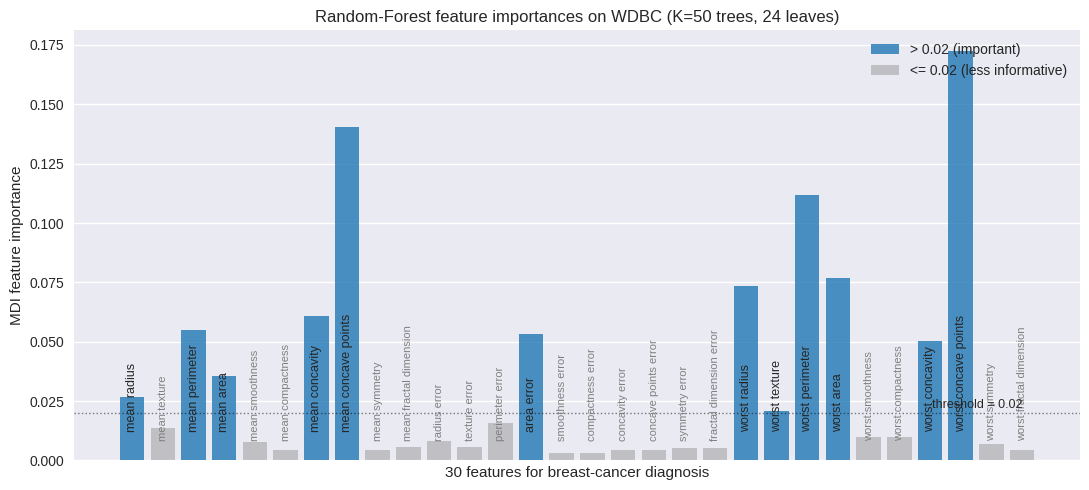

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 5))

idx = np.arange(len(dataset['feature_names']))
imp_mask  = rf_imp.feature_importances_ >= importance_threshold
rest_mask = ~imp_mask

# Bars: important features in solid blue, rest in faded grey
ax.bar(idx[imp_mask],  rf_imp.feature_importances_[imp_mask],
       color='#1f77b4', alpha=0.80, label=f'> {importance_threshold} (important)')
ax.bar(idx[rest_mask], rf_imp.feature_importances_[rest_mask],
       color='gray',    alpha=0.40, label=f'<= {importance_threshold} (less informative)')

# Annotate every feature with its name
for i, (feat, imp) in enumerate(zip(dataset['feature_names'], rf_imp.feature_importances_)):
    if imp >= importance_threshold:
        ax.text(i, 0.012, feat, ha='center', va='bottom', rotation=90, fontsize=9)
    else:
        ax.text(i, 0.008, feat, ha='center', va='bottom', rotation=90, fontsize=8, color='gray')

ax.axhline(importance_threshold, color='k', linestyle=':', linewidth=1, alpha=0.5)
ax.text(29, importance_threshold + 0.002, f'threshold = {importance_threshold}', ha='right', fontsize=9)

ax.set_xticks([])
ax.set_xlabel('30 features for breast-cancer diagnosis')
ax.set_ylabel('MDI feature importance')
ax.set_title('Random-Forest feature importances on WDBC (K=50 trees, 24 leaves)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

**Layer 1 -- what the chart shows.** Twelve **blue bars** (importance $> 0.02$) carry the diagnostic signal; eighteen **grey bars** (importance $\le 0.02$) hover near zero. The two tallest bars -- `worst concave points` ($0.173$) and `mean concave points` ($0.141$) -- visually dwarf the rest, exactly matching the textual ranking in §2.8.6.

**Layer 2 -- a stakeholder-ready picture.** The bar chart is the single most important *deliverable* of the entire chapter as far as a non-technical audience is concerned. It says, in one image: **"these twelve measurements are doing all the diagnostic work; the other eighteen could be cut from data collection without loss."** That is a recommendation a hospital's lab manager can act on -- not an ROC curve, not a confusion matrix, and certainly not a neural-network architecture diagram.

**Layer 3 -- the gap to interpret carefully.** The grey bars are not zero -- their summed importance is $0.1225$ ($12.25\%$). They are the *redundant cousins* of the blue bars; if we removed all 18 grey features and re-trained, the MDI mass would simply re-distribute across whichever features the trees pick up first. **Importance is not the same as causal contribution**, and the bar chart should be presented to stakeholders with that nuance.

**Layer 4 -- production framing.** *"This single chart, generated from a 50-tree random forest trained in $< 1$ second, gives more interpretable model insight than most sophisticated explainability methods. It is reproducible (`random_state` pinned), auditable (the formula is one equation), and natural to communicate. This is why random forests remain the pragmatic default for medical and regulatory tabular work."*

**Layer 5 -- forward link.** Chapter 9 will replace this MDI bar chart with **SHAP summary plots**, which decompose each prediction into per-feature contributions while still giving an aggregate ranking. The MDI chart shown here is the simplest, fastest, most-stakeholder-friendly version of that same idea -- and is often all you need for a tabular medical baseline.

---

## 2.9 Chapter Summary

We replaced Chapter 1's heterogeneous mixture of model families with three *homogeneous* recipes that decorrelate copies of one base learner. The underlying mathematics was the variance-of-the-mean inequality $\mathrm{Var}(\bar{f}) \ge \rho\sigma_f^2$, which says that **once $K$ is large the only knob left for variance reduction is $\rho$**. Bagging attacks $\rho$ by resampling rows; random forests attack it again by resampling columns at every split; extra trees attack it a third time by also randomising the split thresholds. The 0.632/0.368 bootstrap derivation gave us OOB validation as a free side-effect, and the MDI formula gave us free feature importances. On WDBC ($p = 30$) the expected ordering held: RandomForest $\approx$ ExtraTrees $\succ$ Bagging at $K = 19$, with all three above $94\%$ accuracy. On two-moons ($p = 2$) the ordering reversed -- a useful reminder that *defaults are tuned for typical datasets, not all datasets*.

The chapter also revealed three practical findings that the textbook flags but the source code under-emphasises:

1. **Decision-boundary visualisations** make the bias-variance story tangible: bagging smooths jagged single-tree boundaries; random forests make individual trees spikier (axis-aligned) but the ensemble smoother.
2. **Parallelisation via `n_jobs=-1`** is bounded by Amdahl's law -- on a 2-CPU sandbox we measured $\le 1.2\times$ speedup, while a 6-core machine can deliver $\sim 4\times$. The advice is *always set `n_jobs=-1`*; the realised gain depends on hardware.
3. **The base-learner complexity sweep** is the second axis of bias-variance: too few leaves $\Rightarrow$ high bias; too many leaves $\Rightarrow$ training error vanishes but test error plateaus. The sweet spot for WDBC is `max_leaf_nodes` $\in [8, 24]$.

Concept | Single tree | Bagging | Random Forest | Extra Trees
---|---|---|---|---
Source of diversity | -- | bootstrap rows | rows + random feature subsets | rows + features + random thresholds
Implied $\rho$ | -- | high | medium | low
Variance floor $\rho\sigma_f^2$ | -- | high | medium | low
Bias per tree | low | low | slightly higher | highest
Free OOB validation | no | yes | yes | yes (`bootstrap=True`)
Feature importance for free | yes | from base trees | yes (MDI) | yes (MDI)
Parallelisable training | -- | yes | yes | yes
WDBC test accuracy at $K{=}19$ | -- | $94.58\%$ | $\mathbf{95.14\%}$ | $95.10\%$
Two-moons test accuracy at $K{=}500$ | $84.85\%$ | $\mathbf{92.93\%}$ | $89.90\%$ | --
Top-feature MDI on WDBC | -- | -- | $0.173$ (worst concave points) | similar
Top-feature univariate $\lvert r \rvert$ on WDBC | -- | -- | $0.7936$ (same feature) | --

**Where this leads.** Chapter 3 will replace the simple majority-vote / mean aggregator with a *learned* meta-model -- **stacking**. That is the move that lets an ensemble break through the "best individual member" ceiling we hit at the end of Chapter 1. Chapters 4-7 will switch from parallel to **sequential** training (boosting), trading the variance-reduction angle for a bias-reduction angle. The bootstrap, OOB, MDI, and decision-boundary intuitions we built here will return in nearly every subsequent chapter.